In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

rc('text', usetex=True)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

The Z4 scan grid is:
- `mu`  : `[0.02, 0.05, 0.10]`  — physical mass scale
- `beta = 3λ₂/√(8λ₁)` : `[0.01, 0.05, 0.10, 0.40, 1, 2]`  — Z4 breaking strength (> 0, with U(1) reached as β → 0)
- Fixed: `H0 = 1.0*mu`, `kCutOff = 3`

Output columns in `average_energies.txt` (after the standard 9):
- Column 10 → `Scal_type_1`  (adjacent walls, θ → θ+π/2)
- Column 11 → `Scal_type_2`  (diagonal walls, θ → θ+π)

Wall widths in program units:
- **Type 1** (angular path): `δ̃₁ = μ/√(8λ₂)` with `λ₂(μ,β)` from `β = 3λ₂/√(8λ₁)` and `v=1` — shrinks as β grows
- **Type 2** (radial path through origin): `δ̃₂ ≈ 1/√2 ≈ 0.71` — independent of β

In [3]:
BASE    = "/mt/user-batch/dpasari/scan_z4/"
H0_RATIO = 1.0

MU_VALS      = [ 0.05, 0.10]
# BETA_VALS    = [0.001,0.2, 0.25, 1,5,7] 
BETA_VALS    = [0.01,0.05, 0.1, 0.4,1,2] 
KCUTOFF_VALS = [ 1,3,5]

# ── Colour = mu,  linestyle = beta,  linewidth = kcutoff ──────────────────────
mu_colors = {
    0.02: '#1f77b4',   # blue
    0.05: '#d62728',   # red
    0.10: '#2ca02c',   # green
    0.5:  'purple',   
}

line_styles = ['solid', 'dashed', 'dashdot', 'dotted', (0, (3, 1, 1, 1, 1, 1)), (0, (5, 1))]
beta_ls = {b: line_styles[i % len(line_styles)] for i, b in enumerate(BETA_VALS)}

kcutoff_lw = {1: 1.5, 3: 2.5, 5: 3.5}   # linewidth encodes kCutOff

# ── Lattice / physics constants ───────────────────────────────────────────────
LSIDE = 100
N_LAT = 512
DX    = LSIDE / N_LAT

def float_str(x):
    return f"{x:g}".replace(".", "p")

def h0_label(ratio):
    return f"H{f'{ratio:g}'.replace('.','p')}mu"

def couplings_from_mu_beta(mu, beta):
    c = beta * np.sqrt(8.0) / 3.0
    x = mu * (c + np.sqrt(1.0 + c**2))
    lambda1 = x**2
    lambda2 = c * x
    return lambda1, lambda2

def result_dir(mu, beta, kcutoff):
    mu_s   = float_str(mu)
    beta_s = float_str(beta)
    hl     = h0_label(H0_RATIO)
    return f"{BASE}results_z4_mu{mu_s}_beta{beta_s}_{hl}_k{kcutoff}/"

# ── Wall width formulas in program units ──────────────────────────────────────
def wall_width_type1(mu, beta):
    """δ̃₁ = mu/sqrt(8*lambda2), with lambda2 from (mu, beta)."""
    _, lambda2 = couplings_from_mu_beta(mu, beta)
    return mu / np.sqrt(8.0 * lambda2)

def wall_width_type2():
    """δ̃₂ ≈ 1/√2  — type-2 (diagonal) wall width (Higgs path)."""
    return 1.0 / np.sqrt(2.0)

print("Wall widths in program units (δ̃ = wall_width / dx_prog):")
print(f"  Type 2 (diagonal): δ̃₂ = {wall_width_type2():.3f}  →  {wall_width_type2()/DX:.1f} grid pts")
print()
print(f"  Type 1 (adjacent):")
for mu in MU_VALS:
    for beta in BETA_VALS:
        d1 = wall_width_type1(mu, beta)
        print(f"    mu={mu}, beta={beta}: δ̃₁ = {d1:.3f}  →  {d1/DX:.1f} grid pts")

Wall widths in program units (δ̃ = wall_width / dx_prog):
  Type 2 (diagonal): δ̃₂ = 0.707  →  3.6 grid pts

  Type 1 (adjacent):
    mu=0.05, beta=0.01: δ̃₁ = 0.810  →  4.1 grid pts
    mu=0.05, beta=0.05: δ̃₁ = 0.356  →  1.8 grid pts
    mu=0.05, beta=0.1: δ̃₁ = 0.246  →  1.3 grid pts
    mu=0.05, beta=0.4: δ̃₁ = 0.107  →  0.5 grid pts
    mu=0.05, beta=1: δ̃₁ = 0.053  →  0.3 grid pts
    mu=0.05, beta=2: δ̃₁ = 0.029  →  0.1 grid pts
    mu=0.1, beta=0.01: δ̃₁ = 1.146  →  5.9 grid pts
    mu=0.1, beta=0.05: δ̃₁ = 0.503  →  2.6 grid pts
    mu=0.1, beta=0.1: δ̃₁ = 0.347  →  1.8 grid pts
    mu=0.1, beta=0.4: δ̃₁ = 0.151  →  0.8 grid pts
    mu=0.1, beta=1: δ̃₁ = 0.076  →  0.4 grid pts
    mu=0.1, beta=2: δ̃₁ = 0.041  →  0.2 grid pts


## Loader functions

In [4]:
def load_energies(path):
    """
    Load average_energies.txt for the Z4 model.

    Fixed columns (9):
      t, Ek_1, Ek_2, Eg_1, Eg_2, Ev_1, Ev_2, Ev_3, E_tot
    Wall columns (2 for Z4):
      Scal_type_1 (adjacent), Scal_type_2 (diagonal)
    """
    fpath = os.path.join(path, "average_energies.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        print(f"[load_energies] NOT FOUND: {fpath}")
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    if data.shape[1] < 11:
        print(f"[load_energies] Only {data.shape[1]} columns — wall columns missing? ({fpath})")
        return None

    return {
        "eta":    data[:, 0],
        "Ek_1":   data[:, 1],
        "Ek_2":   data[:, 2],
        "Eg_1":   data[:, 3],
        "Eg_2":   data[:, 4],
        "Ev_1":   data[:, 5],
        "Ev_2":   data[:, 6],
        "Ev_3":   data[:, 7],
        "E_tot":  data[:, 8],
        "scal1":  data[:, 9],    # Scal_type_1  (adjacent)
        "scal2":  data[:, 10],   # Scal_type_2  (diagonal)
    }


def load_scalar(path, idx):
    """Load average_scalar_{idx}.txt."""
    fpath = os.path.join(path, f"average_scalar_{idx}.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return {
        "eta":         data[:, 0],
        "phi":         data[:, 1],
        "phi_prime":   data[:, 2],
        "phi2":        data[:, 3],
        "phi_prime2":  data[:, 4],
        "rms_phi":     data[:, 5],
        "rms_phi_p":   data[:, 6],
    }


def load_scale_factor(path):
    """Load average_scale_factor.txt."""
    fpath = os.path.join(path, "average_scale_factor.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return {
        "eta": data[:, 0],
        "a":   data[:, 1],
        "aprime":   data[:, 2],
        "H":   data[:, 3],
    }

## Load all runs

In [5]:
datasets = []

for kcutoff in KCUTOFF_VALS:
    for mu in MU_VALS:
        for beta in BETA_VALS:
            lambda1, lambda2 = couplings_from_mu_beta(mu, beta)

            path  = result_dir(mu, beta, kcutoff)
            label = rf"$\mu={mu},\;\beta={beta},\;k={kcutoff}$"

            en = load_energies(path)
            sf = load_scale_factor(path)
            s0 = load_scalar(path, 0)
            s1 = load_scalar(path, 1)

            status = "OK" if (en is not None and sf is not None) else "MISSING"
            print(f"{status}  {label:50s}   {path}")

            datasets.append({
                "label":        label,
                "mu":           mu,
                "beta":         beta,
                "kcutoff":      kcutoff,
                "lambda1":      lambda1,
                "lambda2":      lambda2,
                "color":        mu_colors[mu],
                "ls":           beta_ls[beta],
                "lw":           kcutoff_lw[kcutoff],
                "energies":     en,
                "scale_factor": sf,
                "scalar_0":     s0,
                "scalar_1":     s1,
            })

ready = [d for d in datasets if d["energies"] is not None and d["scale_factor"] is not None]
print(f"\nReady: {len(ready)} / {len(datasets)}")

OK  $\mu=0.05,\;\beta=0.01,\;k=1$                        /mt/user-batch/dpasari/scan_z4/results_z4_mu0p05_beta0p01_H1mu_k1/
OK  $\mu=0.05,\;\beta=0.05,\;k=1$                        /mt/user-batch/dpasari/scan_z4/results_z4_mu0p05_beta0p05_H1mu_k1/
OK  $\mu=0.05,\;\beta=0.1,\;k=1$                         /mt/user-batch/dpasari/scan_z4/results_z4_mu0p05_beta0p1_H1mu_k1/
OK  $\mu=0.05,\;\beta=0.4,\;k=1$                         /mt/user-batch/dpasari/scan_z4/results_z4_mu0p05_beta0p4_H1mu_k1/
OK  $\mu=0.05,\;\beta=1,\;k=1$                           /mt/user-batch/dpasari/scan_z4/results_z4_mu0p05_beta1_H1mu_k1/
OK  $\mu=0.05,\;\beta=2,\;k=1$                           /mt/user-batch/dpasari/scan_z4/results_z4_mu0p05_beta2_H1mu_k1/
OK  $\mu=0.1,\;\beta=0.01,\;k=1$                         /mt/user-batch/dpasari/scan_z4/results_z4_mu0p1_beta0p01_H1mu_k1/
OK  $\mu=0.1,\;\beta=0.05,\;k=1$                         /mt/user-batch/dpasari/scan_z4/results_z4_mu0p1_beta0p05_H1mu_k1/
OK  $\mu=0.1,\;\be

## Plot helpers

In [6]:
def paper_ax(ax, xlabel=r"$\eta$", ylabel="", title=""):
    ax.set_xlabel(xlabel, fontsize=28)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=28)
    if title:
        ax.set_title(title, fontsize=22)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=22, pad=8)
    ax.tick_params(which='major', length=10)
    ax.tick_params(which='minor', length=5)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def make_legend_handles():
    """Shared legend: colour = mu, linestyle = beta, linewidth = kcutoff."""
    mu_handles = [Line2D([0],[0], color=mu_colors[m], lw=3,
                         label=rf"$\mu = {m}$") for m in MU_VALS]
    beta_handles = [Line2D([0],[0], color='k', lw=3, linestyle=beta_ls[e],
                           label=rf"$\beta = {e}$") for e in BETA_VALS]
    k_handles = [Line2D([0],[0], color='k', lw=kcutoff_lw[k],
                        label=rf"$k_{{\rm cut}} = {k}$") for k in KCUTOFF_VALS]
    return mu_handles + beta_handles + k_handles


def area_param(en_key, d):
    """Compute A_k = scal_k / (2 a H), aligned in length."""
    en = d["energies"]
    sf = d["scale_factor"]
    n  = min(len(en["eta"]), len(sf["a"])) - 1
    scal = en[en_key][:n]
    a    = sf["a"][:n]
    H    = sf["H"][:n]
    A    = scal / (2.0 * a * H)
    return en["eta"][:n], A

## Wall area parameter — Type 1 (adjacent walls, θ → θ+π/2)

**One panel per `mu` value**, sweeping over `beta` to see Z4 → U(1).

Scaling regime: expect `A₁ ~ const` once the network enters the linear scaling regime.

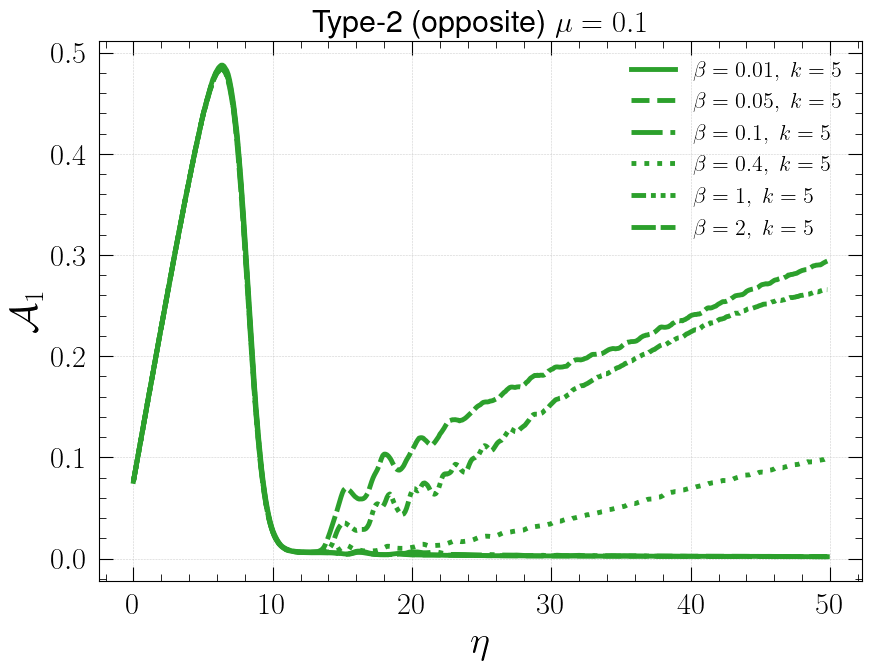

In [7]:
mu_fix = MU_VALS[1]  # mu = 0.02
beta_fix = BETA_VALS[:]
k_fix = KCUTOFF_VALS[2:3]
sub = [d for d in ready if (d["mu"] == mu_fix and d['beta'] in beta_fix and d['kcutoff'] in k_fix)]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal2", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_1$",
         title=fr"Type-2 (non-adjacent)  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall1_area_mu0p05_targeted.pdf", bbox_inches="tight")
plt.show()

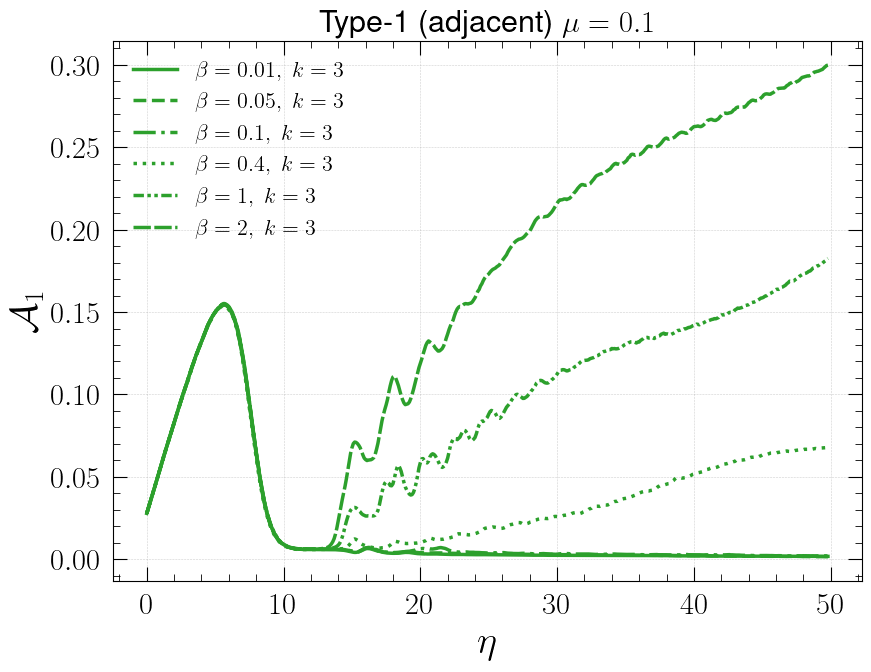

In [8]:
mu_fix = MU_VALS[1]  # mu = 0.02
beta_fix = BETA_VALS[0]
sub = [d for d in ready if (d["mu"] == mu_fix and d['beta'] == beta_fix)]

area_param("scal1",sub[0])

(array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
         3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
         4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
         5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
         6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
         7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
         8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
         9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
        11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
        12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1,
        13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2,
        14.3, 14.4, 14.5, 14.6, 14.7, 

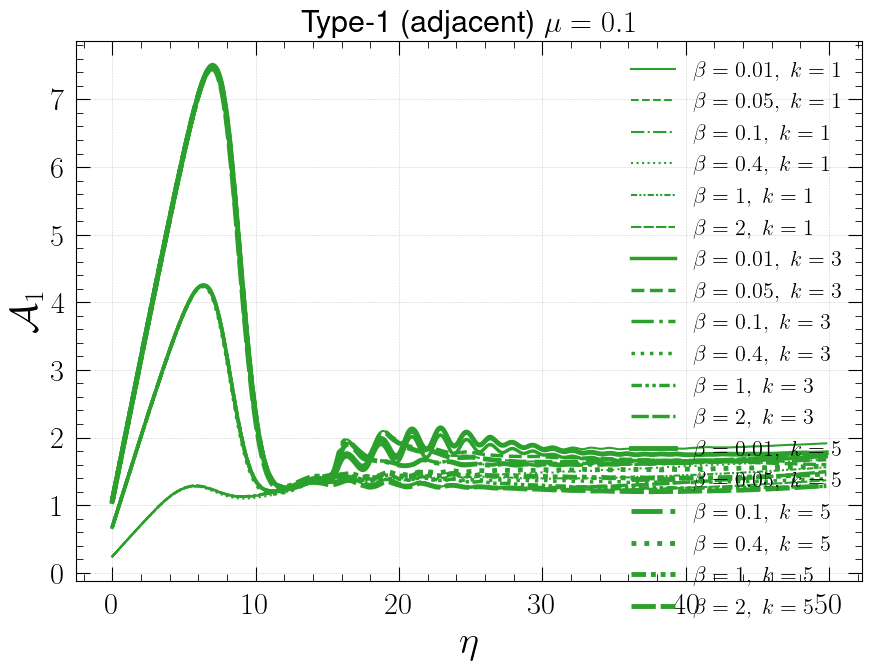

In [9]:
mu_fix = MU_VALS[1]  # mu = 0.02
beta_fix = BETA_VALS[:]
sub = [d for d in ready if (d["mu"] == mu_fix and d['beta'] in beta_fix)]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal1", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_1$",
         title=fr"Type-1 (adjacent)  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall1_area_mu0p1_targeted.pdf", bbox_inches="tight")
plt.show()

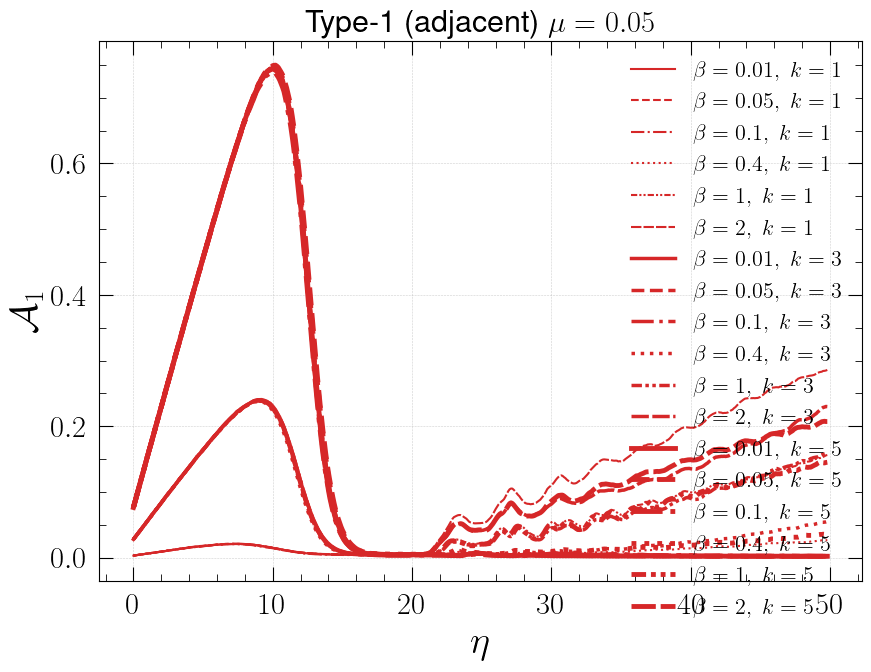

In [10]:
mu_fix = MU_VALS[0]  # mu = 0.02
beta_fix = BETA_VALS[:]
sub = [d for d in ready if (d["mu"] == mu_fix and d['beta'] in beta_fix)]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal2", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_1$",
         title=fr"Type-1 (adjacent)  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall2_area_mu0p05_targeted.pdf", bbox_inches="tight")
plt.show()

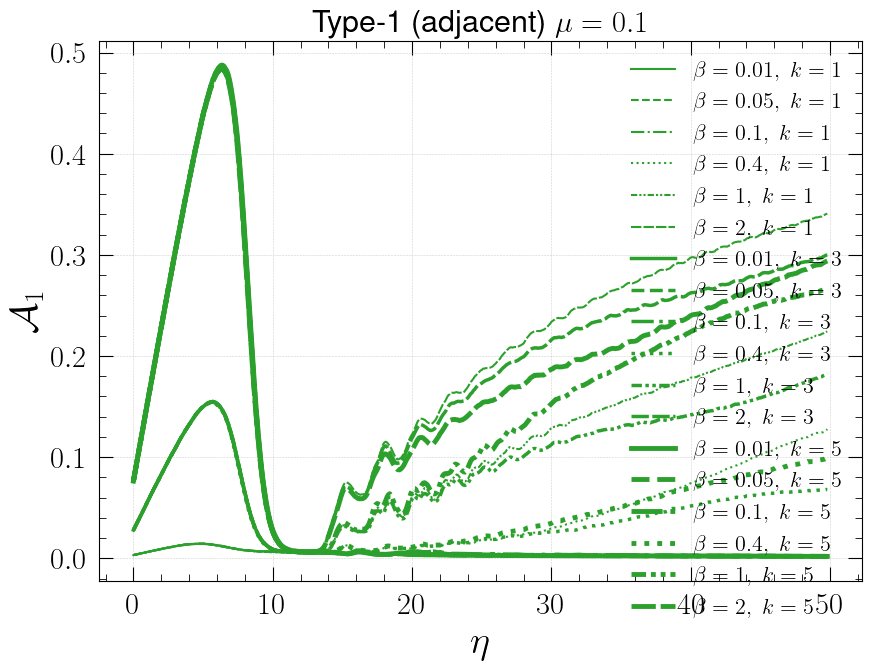

In [11]:
mu_fix = MU_VALS[1]  # mu = 0.02
beta_fix = BETA_VALS[:]
sub = [d for d in ready if (d["mu"] == mu_fix and d['beta'] in beta_fix)]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal2", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_1$",
         title=fr"Type-1 (adjacent)  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall2_area_mu0p1_targeted.pdf", bbox_inches="tight")
plt.show()

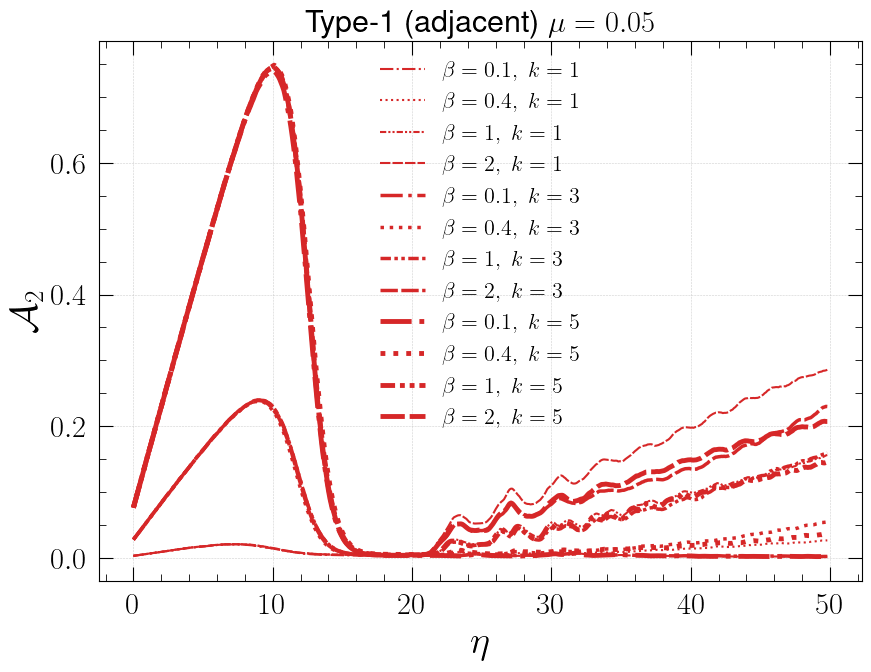

In [12]:
mu_fix = MU_VALS[0]  # mu = 0.02
beta_fix = BETA_VALS[2:]
sub = [d for d in ready if (d["mu"] == mu_fix and d['beta'] in beta_fix)]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal2", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_2$",
         title=fr"Type-1 (adjacent)  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall1_area_mu0p02.pdf", bbox_inches="tight")
plt.show()

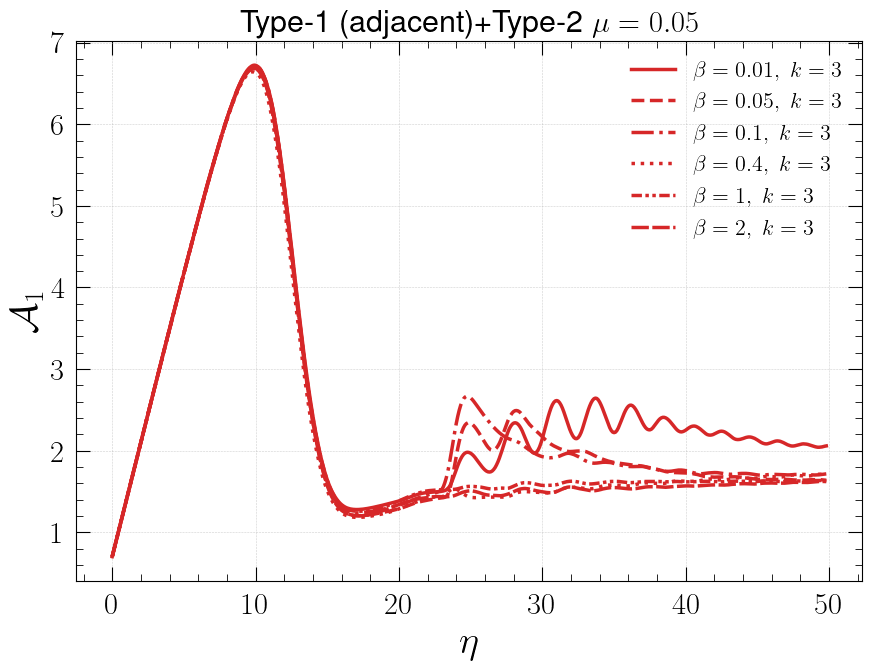

In [17]:
mu_fix = MU_VALS[0]  # mu = 0.02
beta_fix = BETA_VALS[:]
k_fix = KCUTOFF_VALS[1:2]
sub = [d for d in ready if (d["mu"] == mu_fix and d['beta'] in beta_fix and d['kcutoff'] in k_fix)]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal1", d)
    eta, A2 = area_param("scal2", d)
    ax.plot(eta, A+A2, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_1$",
         title=fr"Type-1 (adjacent)+Type-2  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall1_area_mu0p05.pdf", bbox_inches="tight")
plt.show()

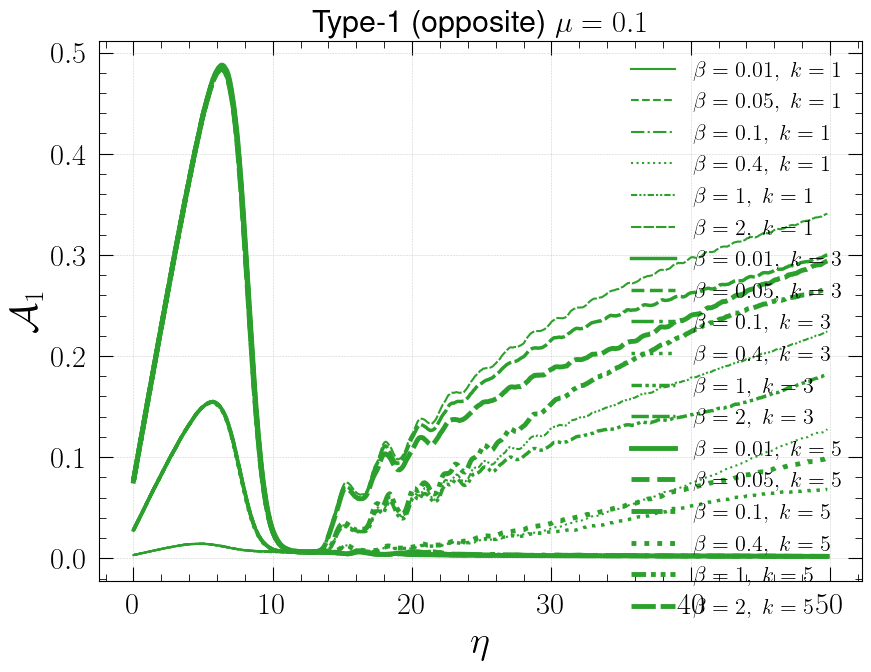

In [52]:
mu_fix = MU_VALS[1]  # mu = 0.05
beta_fix = BETA_VALS[2]
sub = [d for d in ready if (d["mu"] == mu_fix)]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal2", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_1$",
         title=fr"Type-1 (non-adjacent)  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall1_area_mu0p05.pdf", bbox_inches="tight")
plt.show()

In [53]:
area_param("scal2", d)

(array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
         3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
         4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
         5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
         6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
         7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
         8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
         9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
        11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
        12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1,
        13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2,
        14.3, 14.4, 14.5, 14.6, 14.7, 

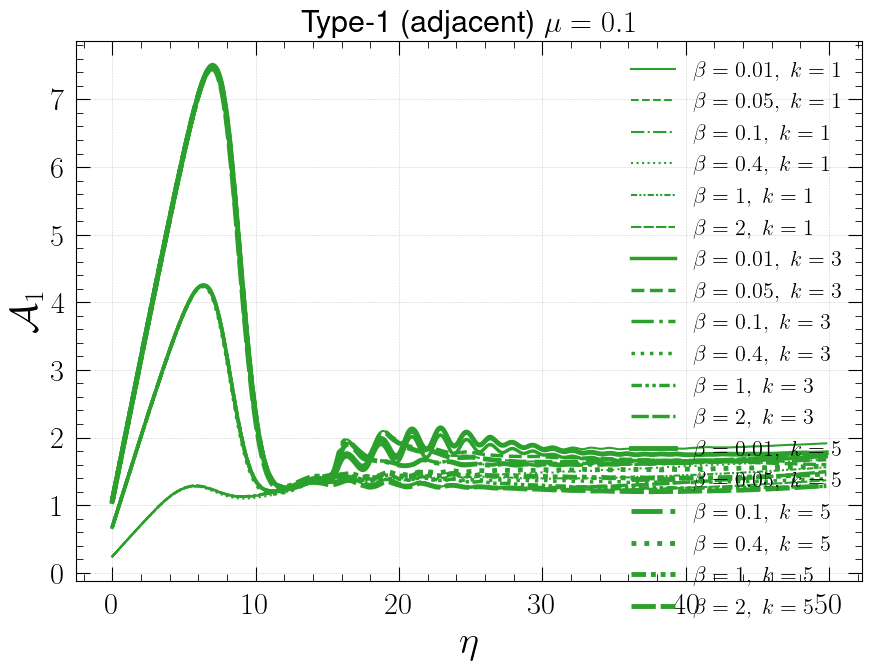

In [54]:
mu_fix = MU_VALS[1]  # mu = 0.1
sub = [d for d in ready if d["mu"] == mu_fix]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal1", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_1$",
         title=r"Type-1 (adjacent)  $\mu = 0.1$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall1_area_mu0p1.pdf", bbox_inches="tight")
plt.show()

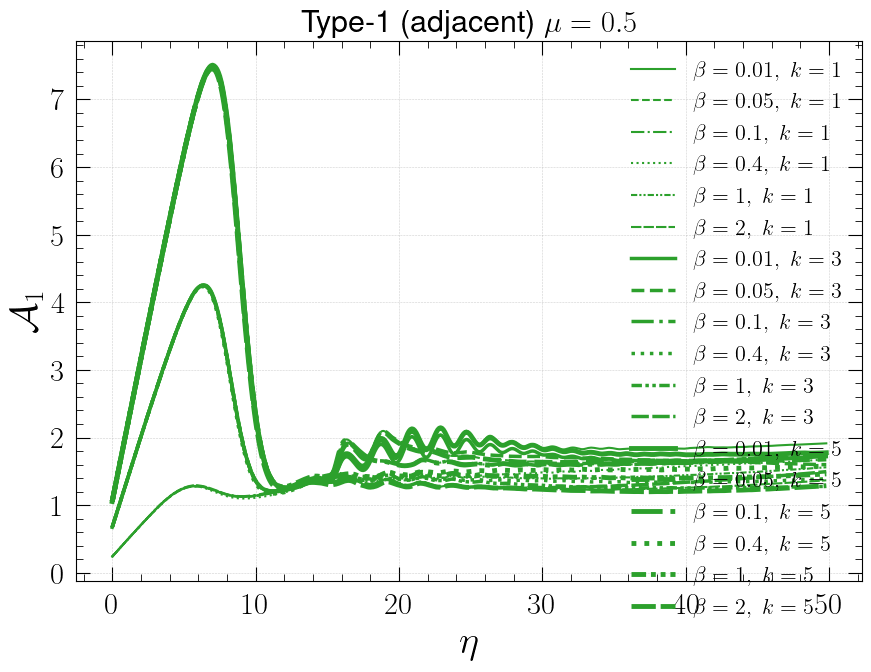

In [55]:
mu_fix = MU_VALS[1]  # mu = 0.1
sub = [d for d in ready if d["mu"] == mu_fix]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal1", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_1$",
         title=r"Type-1 (adjacent)  $\mu = 0.5$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall1_area_mu0p5.pdf", bbox_inches="tight")
plt.show()

## Wall area parameter — Type 2 (diagonal walls, θ → θ+π)

**Same layout.** Diagonal walls connect antipodal vacua — they are energetically
more costly and are expected to split into two type-1 walls.  
As `beta → 0` (U(1) limit) the tension ratio `σ₂/σ₁ → 2`, so type-2 walls
should become less frequent; they may vanish entirely for small `beta`.

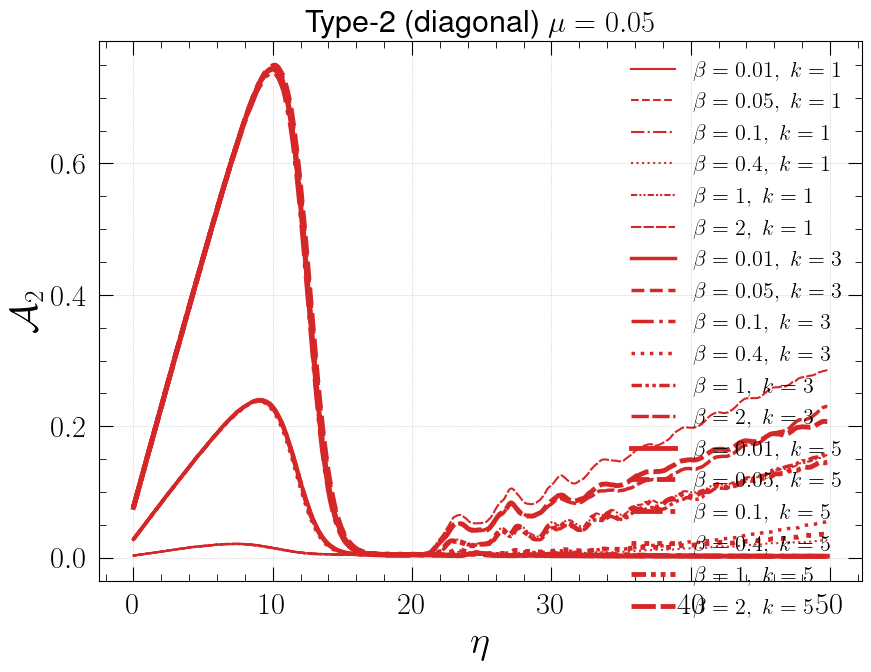

In [56]:
mu_fix = MU_VALS[0]  # mu = 0.02
beta_fix = BETA_VALS[:]
sub = [d for d in ready if (d["mu"] == mu_fix and d["beta"] in beta_fix)]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta = area_param("scal2", d)[0]
    A = area_param("scal2",d)[1]
    A1 = area_param("scal1",d)[1]
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
    # ax.plot(eta, A1, color="pink", linestyle=d["ls"], linewidth=d["lw"],
    #         label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_2$",
         title=fr"Type-2 (diagonal)  $\mu = {mu_fix}$")
# ax.legend(fontsize=16, frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1),)
ax.legend(fontsize=16, frameon=False, loc='upper right',)
# ax.set_ylim(0,0.1)
plt.tight_layout()
plt.savefig("Z4_wall2_area_mu0p02.pdf", bbox_inches="tight")
plt.show()

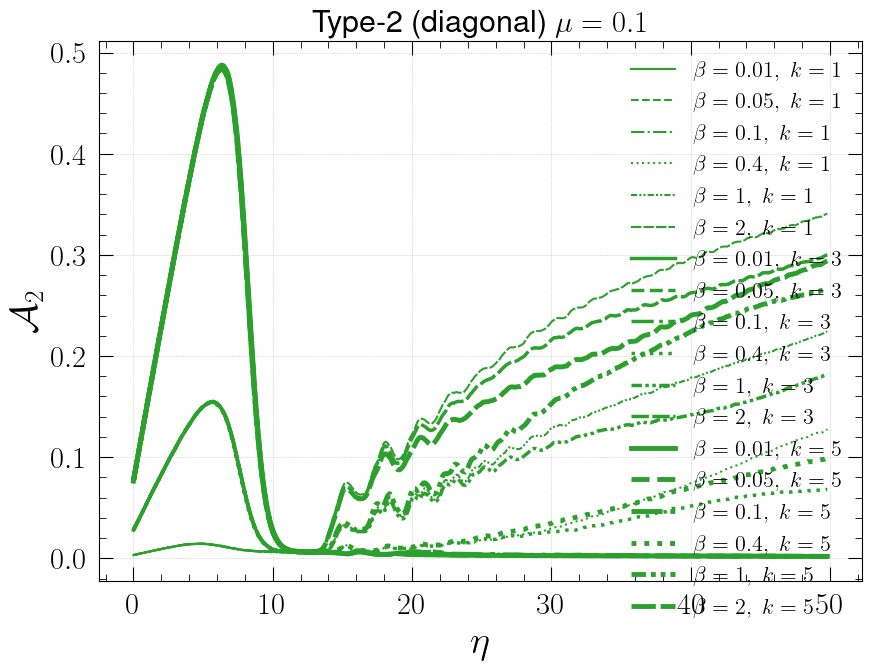

In [57]:
mu_fix = MU_VALS[1]  # mu = 0.05
sub = [d for d in ready if d["mu"] == mu_fix]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal2", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_2$",
         title=fr"Type-2 (diagonal)  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall2_area_mu0p05.pdf", bbox_inches="tight")
plt.show()

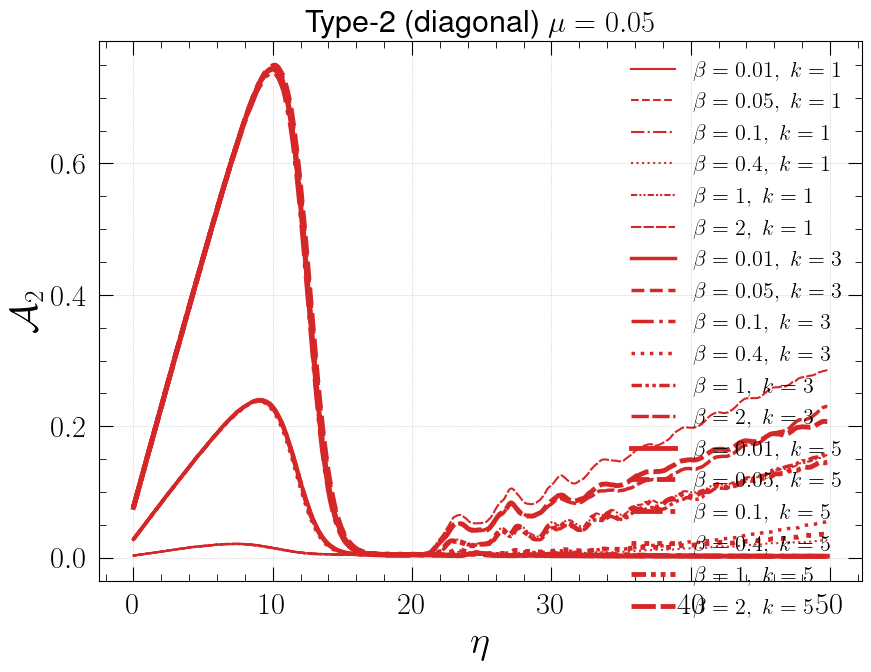

In [58]:
mu_fix = MU_VALS[0]  # mu = 0.1
sub = [d for d in ready if d["mu"] == mu_fix]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal2", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_2$",
         title=fr"Type-2 (diagonal)  $\mu = {mu_fix}$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall2_area_mu0p1.pdf", bbox_inches="tight")
plt.show()

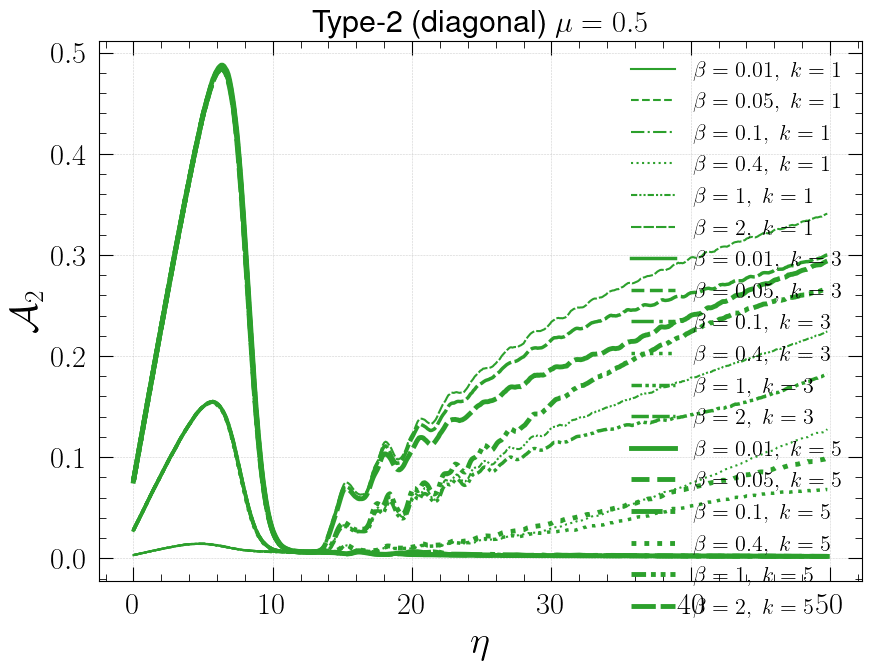

In [59]:
mu_fix = MU_VALS[1]  # mu = 0.1
sub = [d for d in ready if d["mu"] == mu_fix]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    eta, A = area_param("scal2", d)
    ax.plot(eta, A, color=d["color"], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_2$",
         title=r"Type-2 (diagonal)  $\mu = 0.5$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall2_area_mu0p5.pdf", bbox_inches="tight")
plt.show()

## Both wall types side by side — fixed `mu`, sweep `beta`

Direct comparison of type-1 vs type-2 scaling within each run.
Solid = type 1, dashed = type 2; colour = beta.

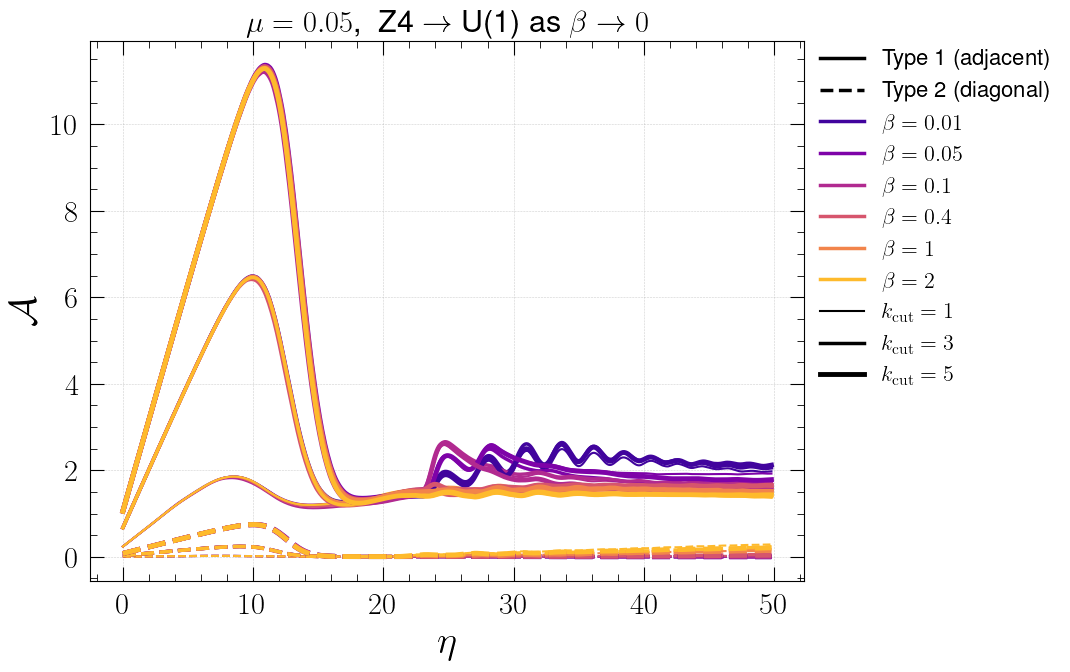

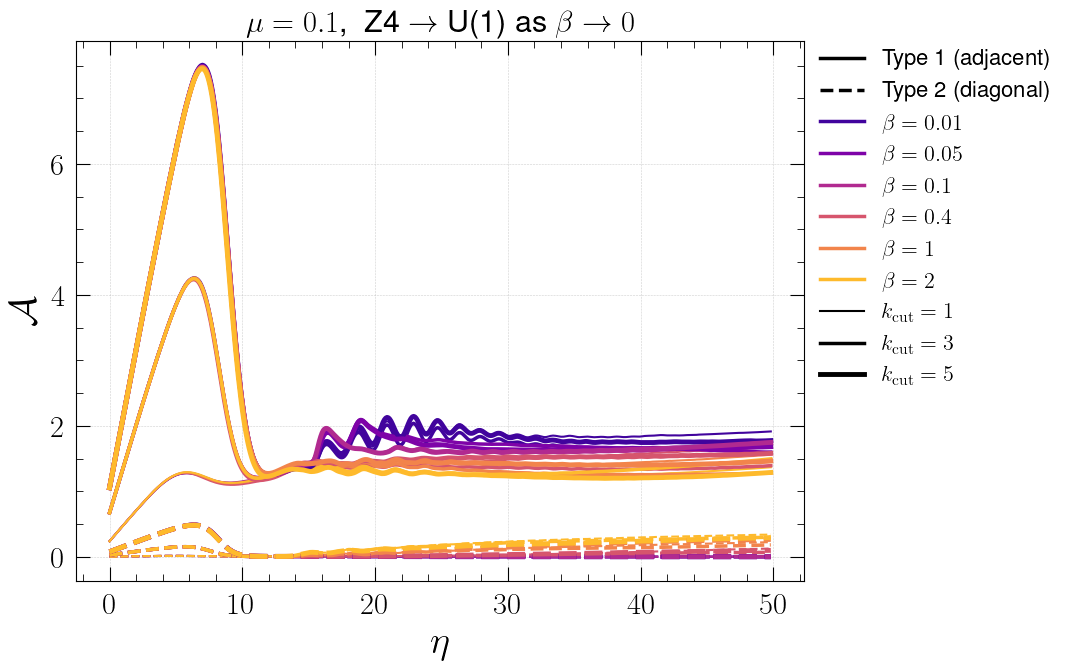

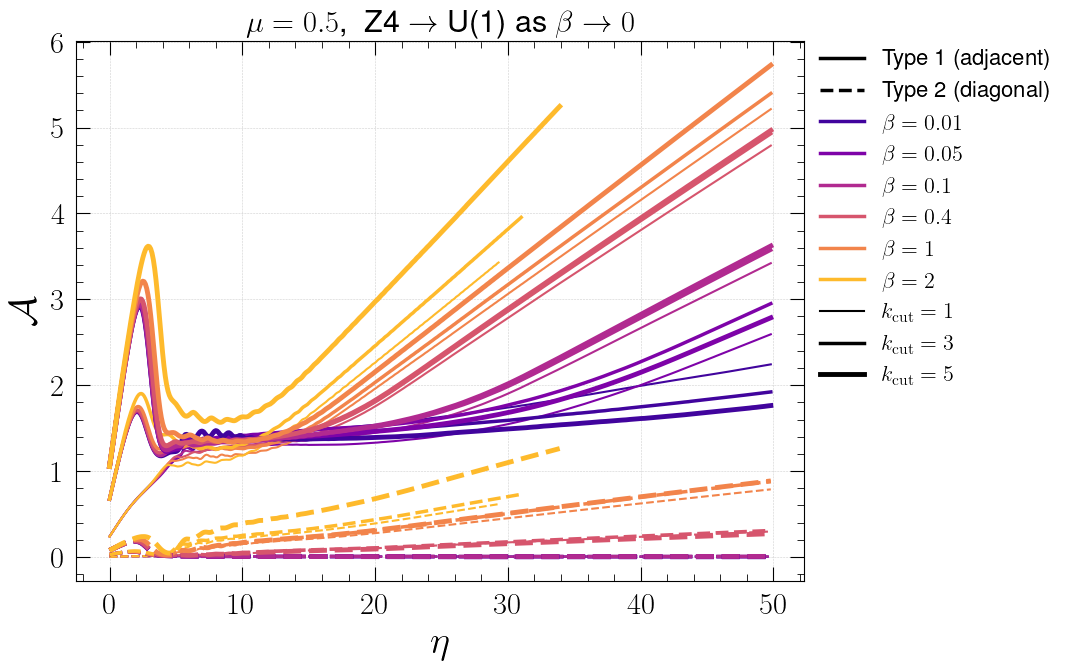

In [60]:
beta_colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(BETA_VALS)))
beta_color_map = dict(zip(BETA_VALS, beta_colors))

for mu_fix in MU_VALS:
    fig, ax = plt.subplots(figsize=(11, 7))
    sub = [d for d in ready if d["mu"] == mu_fix]

    for d in sub:
        c   = beta_color_map[d["beta"]]
        lbl = rf"$\beta = {d['beta']},\;k={d['kcutoff']}$"

        eta1, A1 = area_param("scal1", d)
        eta2, A2 = area_param("scal2", d)

        ax.plot(eta1, A1, color=c, linestyle="solid",  linewidth=d["lw"], label=lbl + " (type 1)")
        ax.plot(eta2, A2, color=c, linestyle="dashed", linewidth=d["lw"], label=lbl + " (type 2)")

    # Legend: type indicator + beta colour + kcutoff linewidth
    type_handles = [
        Line2D([0],[0], color='k', lw=2.5, linestyle='solid',  label='Type 1 (adjacent)'),
        Line2D([0],[0], color='k', lw=2.5, linestyle='dashed', label='Type 2 (diagonal)'),
    ]
    beta_handles = [Line2D([0],[0], color=beta_color_map[e], lw=2.5,
                           label=rf"$\beta = {e}$") for e in BETA_VALS]
    k_handles    = [Line2D([0],[0], color='k', lw=kcutoff_lw[k],
                           label=rf"$k_{{\rm cut}} = {k}$") for k in KCUTOFF_VALS]

    paper_ax(ax, ylabel=r"$\mathcal{A}$",
             title=rf"$\mu = {mu_fix}$,\; Z4 $\to$ U(1) as $\beta \to 0$")
    ax.legend(handles=type_handles + beta_handles + k_handles, fontsize=16, frameon=False,
              loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.tight_layout()
    plt.savefig(f"Z4_both_walls_mu{float_str(mu_fix)}.pdf", bbox_inches="tight")
    plt.show()

## Ratio A₂ / A₁  — diagnostic for wall-type splitting

In the U(1) limit (β → 0) both walls have equal tension so σ₂/σ₁ → 2 and
type-2 walls immediately split.  We expect `A₂/A₁ → 0` as `β → 0`.
For large β, both types co-exist and `A₂/A₁` should approach a finite value.

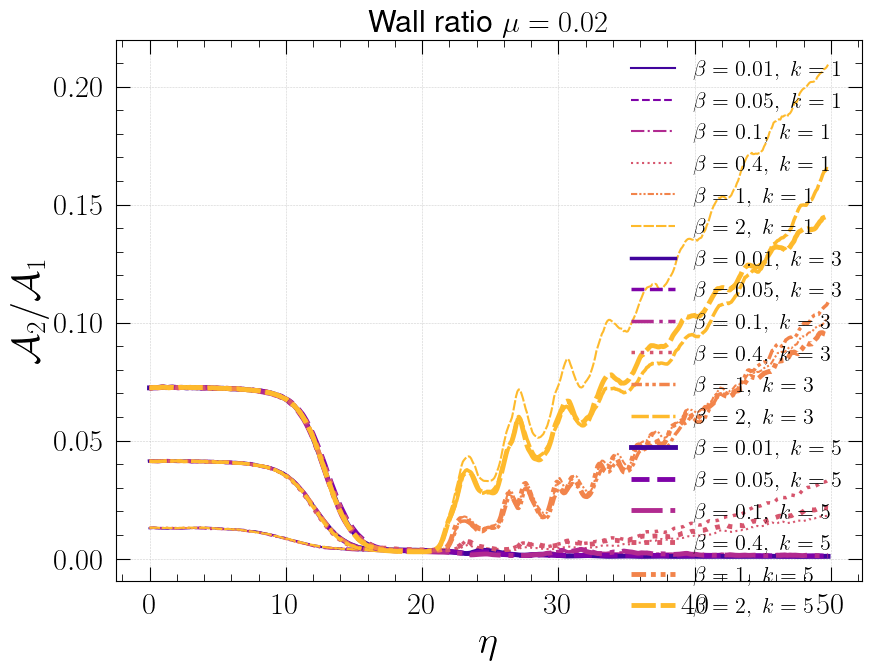

In [61]:
mu_fix = MU_VALS[0]  # mu = 0.02
sub = [d for d in ready if d["mu"] == mu_fix]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    en = d["energies"]
    sf = d["scale_factor"]
    n  = min(len(en["eta"]), len(sf["a"])) - 1
    A1 = en["scal1"][:n] / (2.0 * sf["a"][:n] * sf["H"][:n])
    A2 = en["scal2"][:n] / (2.0 * sf["a"][:n] * sf["H"][:n])
    ratio = np.where(A1 > 1e-12, A2 / A1, np.nan)
    ax.plot(en["eta"][:n], ratio,
            color=beta_color_map[d["beta"]], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_2 / \mathcal{A}_1$",
         title=r"Wall ratio  $\mu = 0.02$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall_ratio_mu0p02.pdf", bbox_inches="tight")
plt.show()

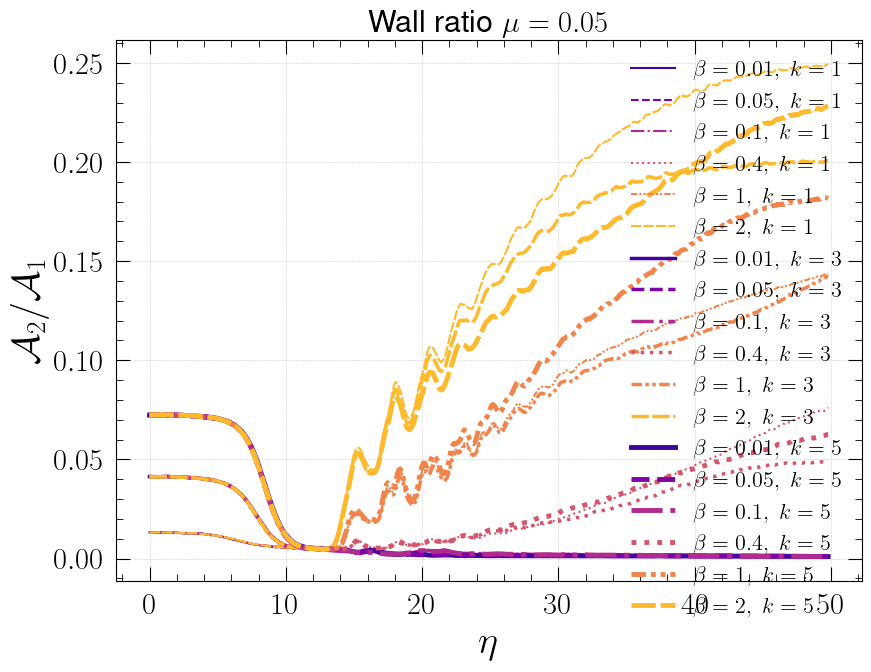

In [62]:
mu_fix = MU_VALS[1]  # mu = 0.05
sub = [d for d in ready if d["mu"] == mu_fix]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    en = d["energies"]
    sf = d["scale_factor"]
    n  = min(len(en["eta"]), len(sf["a"])) - 1
    A1 = en["scal1"][:n] / (2.0 * sf["a"][:n] * sf["H"][:n])
    A2 = en["scal2"][:n] / (2.0 * sf["a"][:n] * sf["H"][:n])
    ratio = np.where(A1 > 1e-12, A2 / A1, np.nan)
    ax.plot(en["eta"][:n], ratio,
            color=beta_color_map[d["beta"]], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_2 / \mathcal{A}_1$",
         title=r"Wall ratio  $\mu = 0.05$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall_ratio_mu0p05.pdf", bbox_inches="tight")
plt.show()

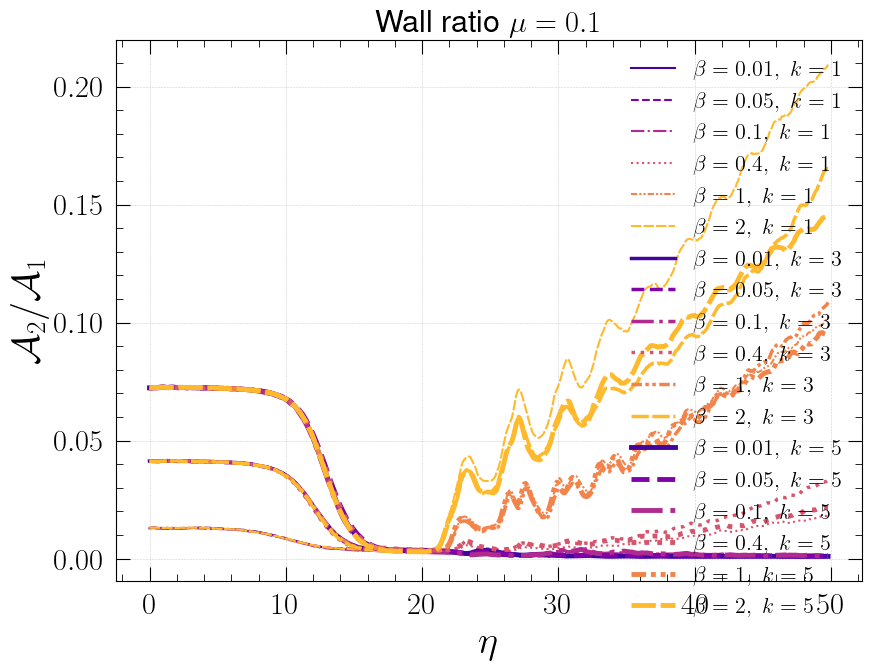

In [63]:
mu_fix = MU_VALS[0]  # mu = 0.1
sub = [d for d in ready if d["mu"] == mu_fix]

fig, ax = plt.subplots(figsize=(9, 7))
for d in sub:
    en = d["energies"]
    sf = d["scale_factor"]
    n  = min(len(en["eta"]), len(sf["a"])) - 1
    A1 = en["scal1"][:n] / (2.0 * sf["a"][:n] * sf["H"][:n])
    A2 = en["scal2"][:n] / (2.0 * sf["a"][:n] * sf["H"][:n])
    ratio = np.where(A1 > 1e-12, A2 / A1, np.nan)
    ax.plot(en["eta"][:n], ratio,
            color=beta_color_map[d["beta"]], linestyle=d["ls"], linewidth=d["lw"],
            label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")
paper_ax(ax, ylabel=r"$\mathcal{A}_2 / \mathcal{A}_1$",
         title=r"Wall ratio  $\mu = 0.1$")
ax.legend(fontsize=16, frameon=False)
plt.tight_layout()
plt.savefig("Z4_wall_ratio_mu0p1.pdf", bbox_inches="tight")
plt.show()

## β sweep at fixed `mu` — Z4 → U(1) transition

Both wall types on the same axis; colour = beta (plasma scale).  
Focus: does the type-1 area parameter converge to a universal value as β → 0?

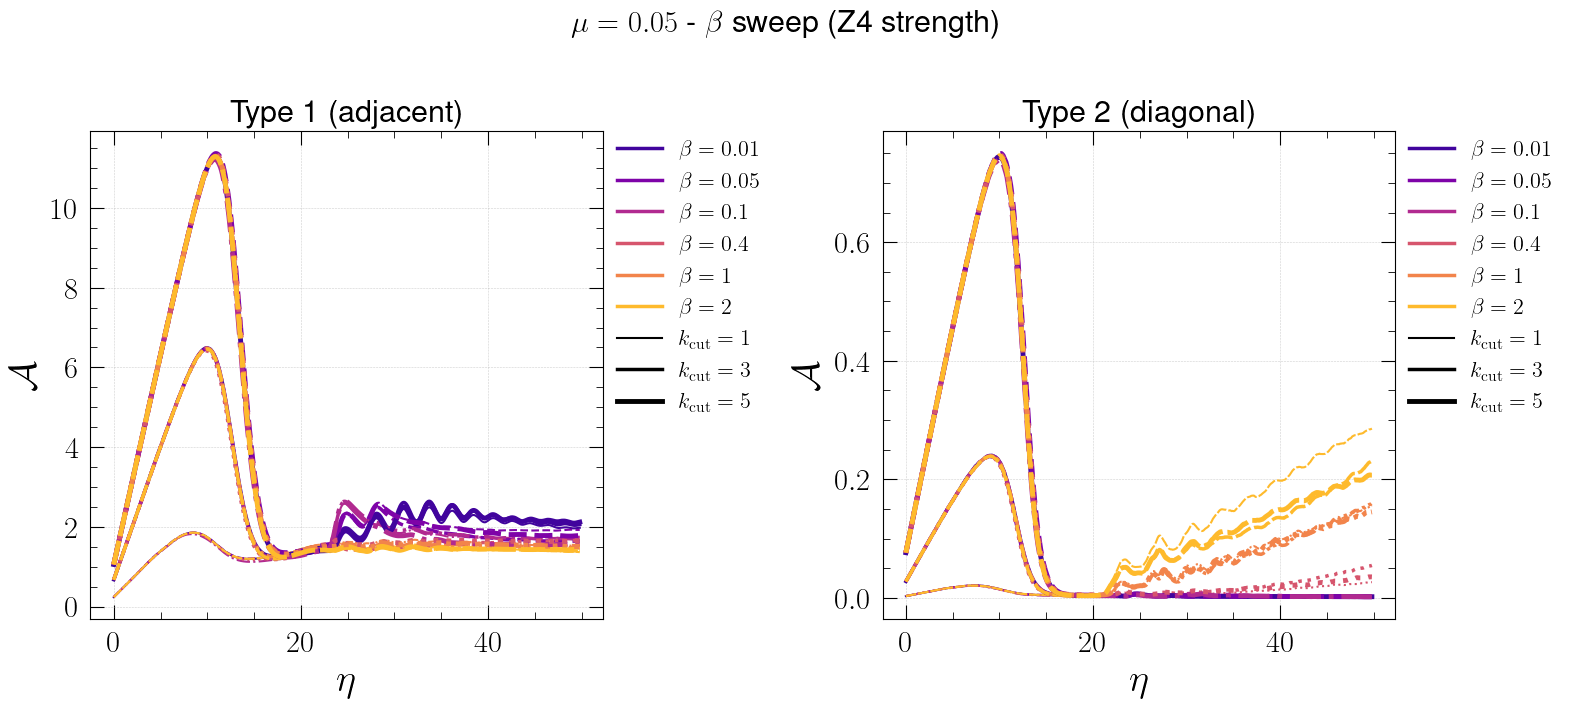

In [64]:
MU_FIX = 0.05   # ← change to 0.02 or 0.10 to see other mu values

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
sub = [d for d in ready if d["mu"] == MU_FIX]

for d in sub:
    c = beta_color_map[d["beta"]]
    for ax_idx, (key, title) in enumerate([("scal1", "Type 1 (adjacent)"),
                                            ("scal2", "Type 2 (diagonal)")]):
        eta, A = area_param(key, d)
        axes[ax_idx].plot(eta, A, color=c, linewidth=d["lw"],
                          linestyle=d["ls"],
                          label=rf"$\beta = {d['beta']},\;k={d['kcutoff']}$")

k_handles = [Line2D([0],[0], color='k', lw=kcutoff_lw[k],
                    label=rf"$k_{{\rm cut}} = {k}$") for k in KCUTOFF_VALS]
beta_h    = [Line2D([0],[0], color=beta_color_map[e], lw=2.5,
                    label=rf"$\beta = {e}$") for e in BETA_VALS]

for ax_idx, title in enumerate(["Type 1 (adjacent)", "Type 2 (diagonal)"]):
    paper_ax(axes[ax_idx], ylabel=r"$\mathcal{A}$", title=title)
    axes[ax_idx].legend(handles=beta_h + k_handles, fontsize=16, frameon=False,
                        loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

fig.suptitle(rf"$\mu = {MU_FIX}$ -  $\beta$ sweep (Z4 strength)", fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig(f"Z4_beta_sweep_mu{float_str(MU_FIX)}.pdf", bbox_inches="tight")
plt.show()

## `mu` sweep at fixed β — scale dependence

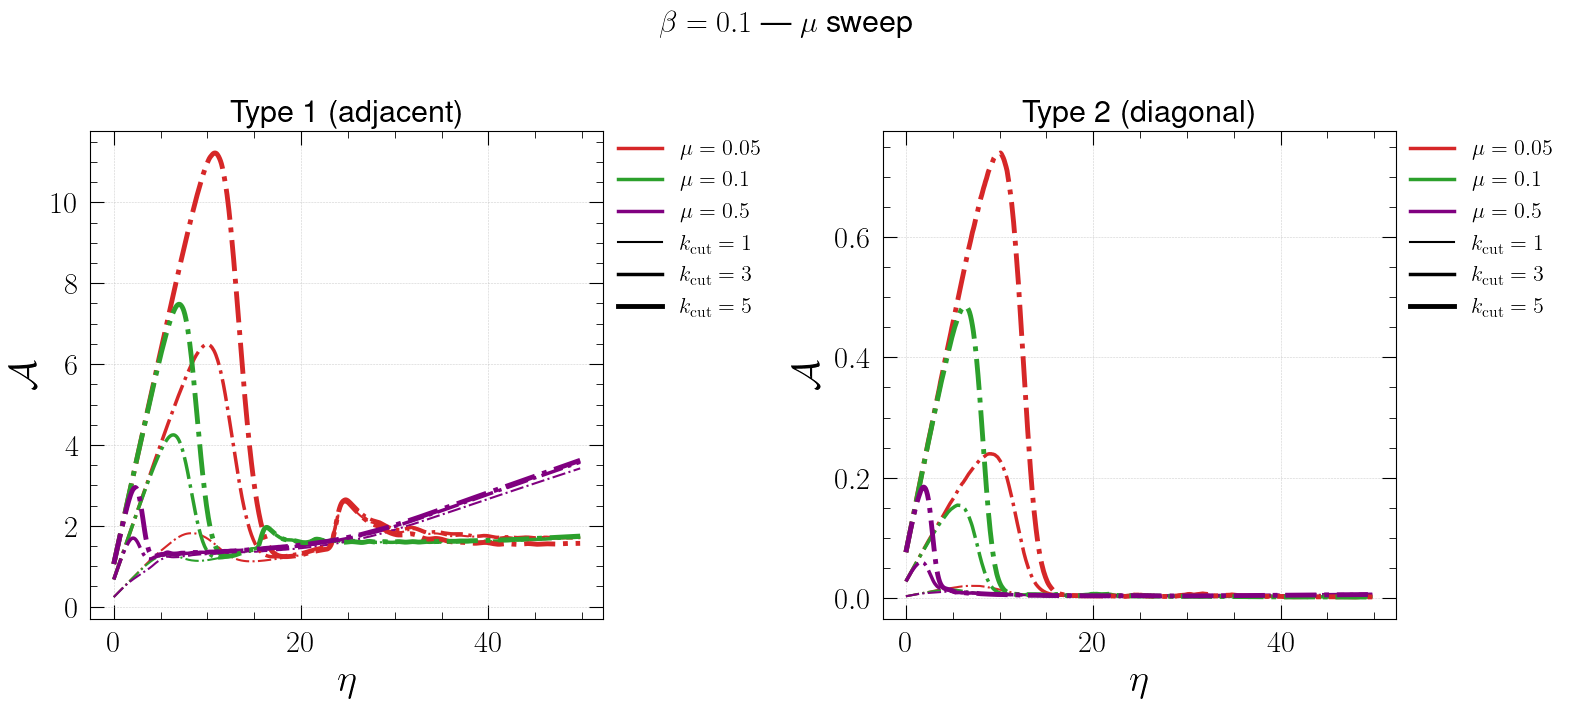

In [65]:
BETA_FIX = 0.10   # ← change to any BETA_VALS entry

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
sub = [d for d in ready if d["beta"] == BETA_FIX]

for d in sub:
    c = mu_colors[d["mu"]]
    for ax_idx, (key, title) in enumerate([("scal1", "Type 1 (adjacent)"),
                                            ("scal2", "Type 2 (diagonal)")]):
        eta, A = area_param(key, d)
        axes[ax_idx].plot(eta, A, color=c, linewidth=d["lw"],
                          linestyle=d["ls"],
                          label=rf"$\mu = {d['mu']},\;k={d['kcutoff']}$")

mu_h   = [Line2D([0],[0], color=mu_colors[m], lw=2.5,
                 label=rf"$\mu = {m}$") for m in MU_VALS]
k_handles = [Line2D([0],[0], color='k', lw=kcutoff_lw[k],
                    label=rf"$k_{{\rm cut}} = {k}$") for k in KCUTOFF_VALS]

for ax_idx, title in enumerate(["Type 1 (adjacent)", "Type 2 (diagonal)"]):
    paper_ax(axes[ax_idx], ylabel=r"$\mathcal{A}$", title=title)
    axes[ax_idx].legend(handles=mu_h + k_handles, fontsize=16, frameon=False,
                        loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

fig.suptitle(rf"$\beta = {BETA_FIX}$  —  $\mu$ sweep", fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig(f"Z4_mu_sweep_beta{float_str(BETA_FIX)}.pdf", bbox_inches="tight")
plt.show()

## Energy budget

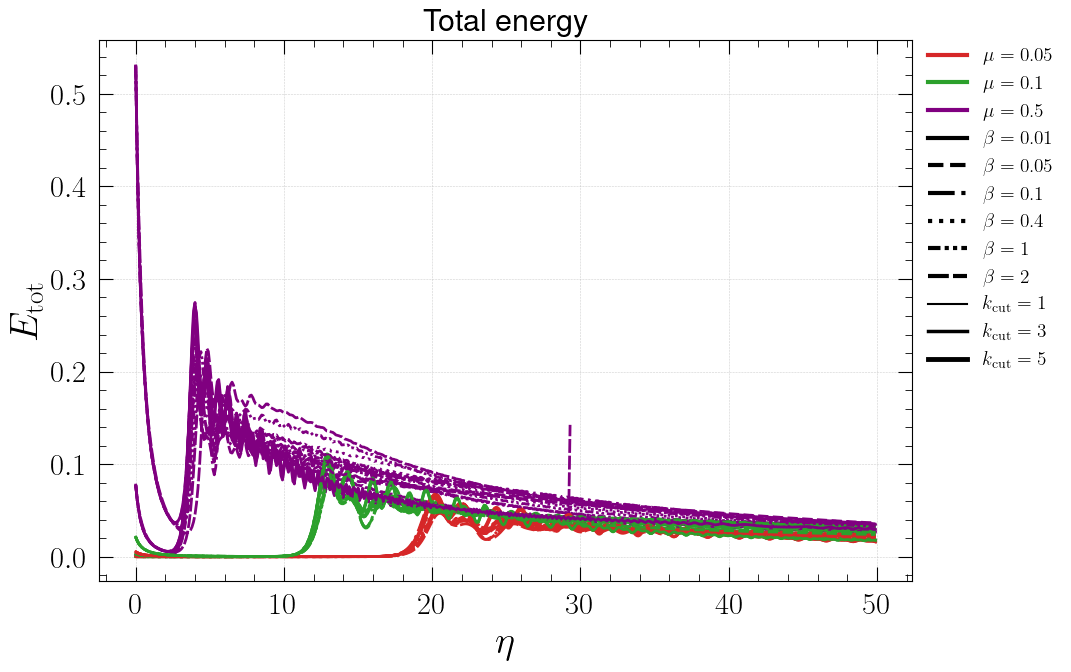

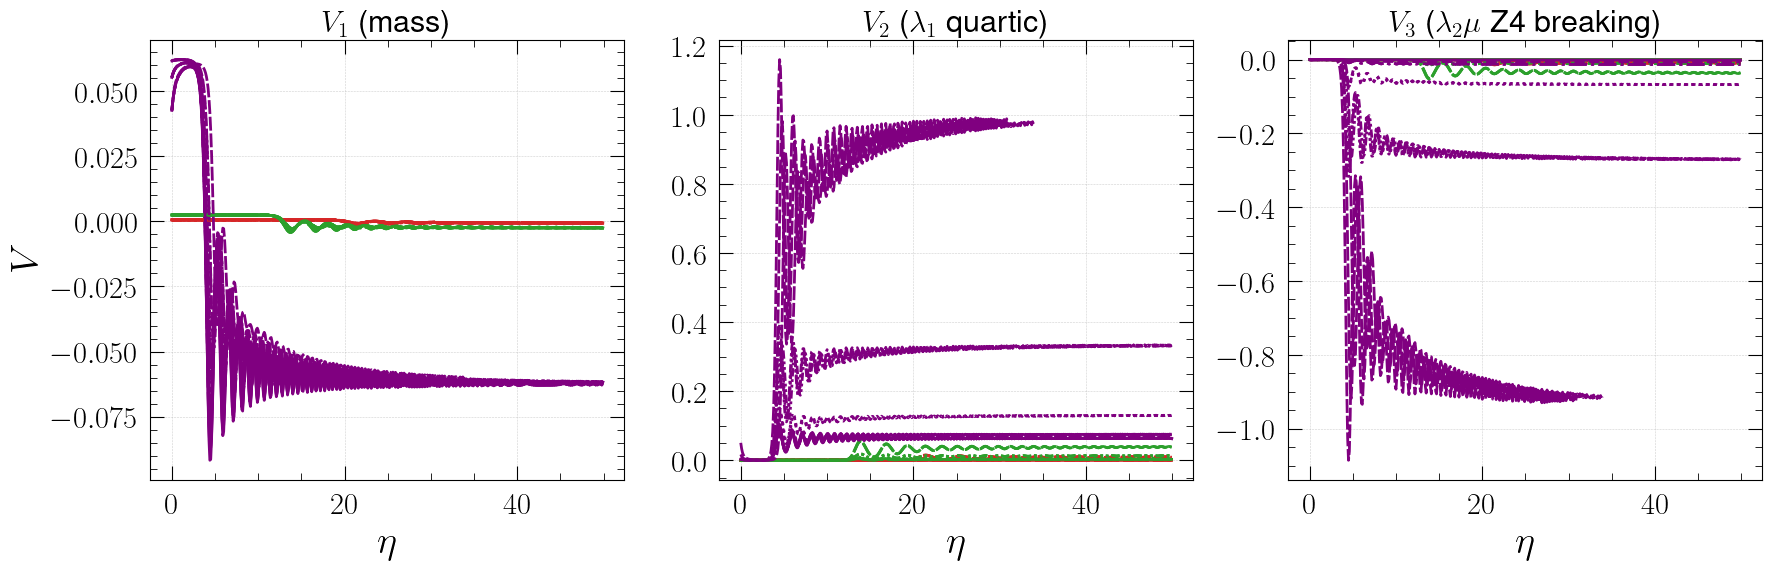

In [66]:
# ── Total energy ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
for d in ready:
    en = d["energies"]
    sc_f = d["scale_factor"]
    ax.plot(en["eta"], en["Ek_1"]*sc_f["a"]/sc_f["H"],
            color=d["color"], linestyle=d["ls"], linewidth=2, label=d["label"])
paper_ax(ax, ylabel=r"$E_{\rm tot}$", title="Total energy")
ax.legend(handles=make_legend_handles(), fontsize=14, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# ── Potential terms ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
for d in ready:
    en = d["energies"]
    for i, key in enumerate(["Ev_1", "Ev_2", "Ev_3"]):
        axes[i].plot(en["eta"], en[key],
                     color=d["color"], linestyle=d["ls"], linewidth=2)
for i, lbl in enumerate([r"$V_1$ (mass)", r"$V_2$ ($\lambda_1$ quartic)",
                          r"$V_3$ ($\lambda_2\mu$ Z4 breaking)"]):
    paper_ax(axes[i], ylabel=r"$V$" if i==0 else "", title=lbl)
plt.tight_layout()
plt.show()

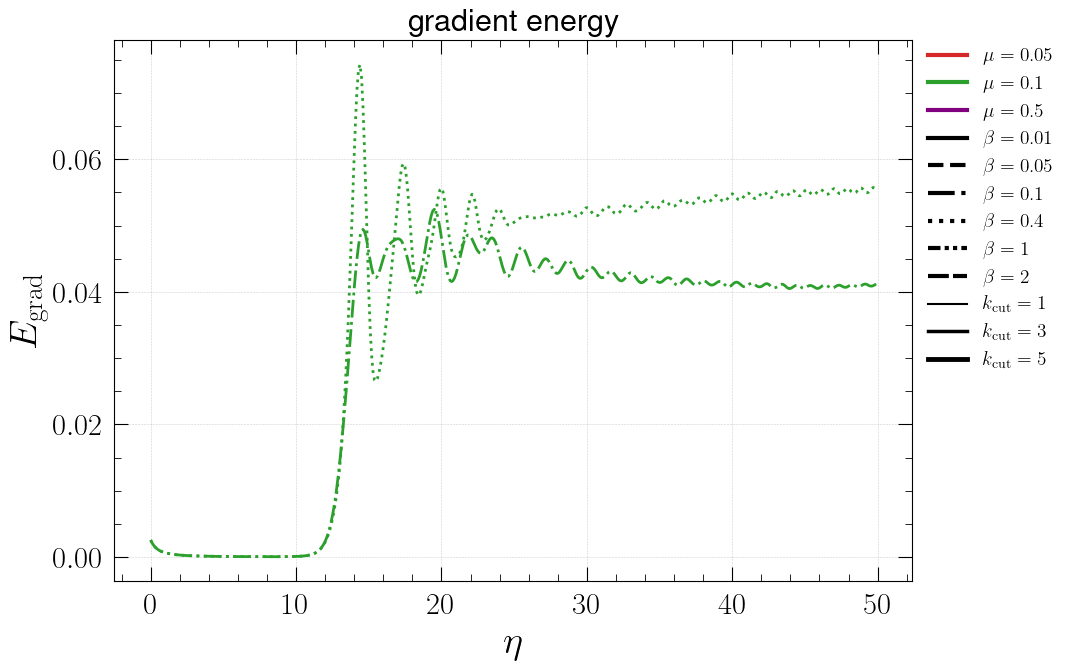

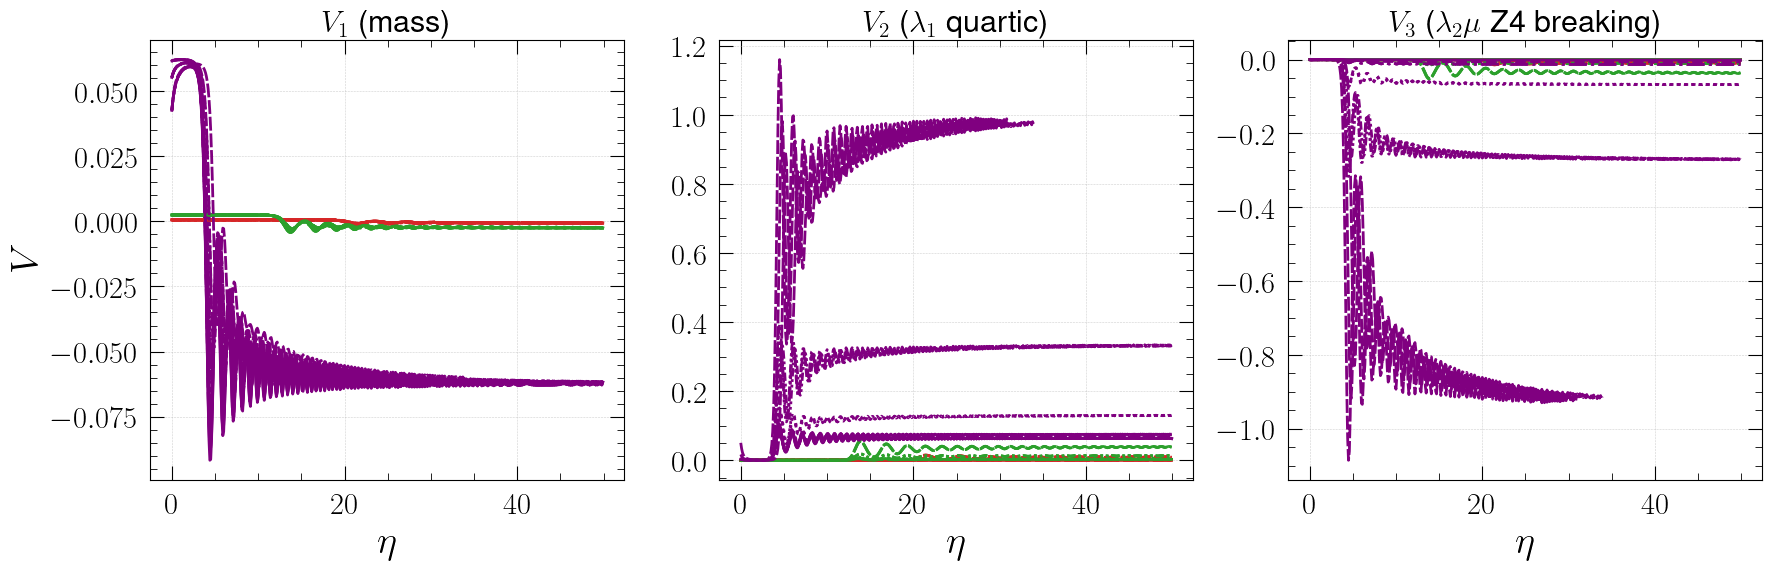

In [73]:
# ── Total energy ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
sub = [d for d in ready if (d["mu"] in [0.1] and d['beta'] in [0.1,0.4] and d['kcutoff'] in [3])]
for d in sub:
    en = d["energies"]
    sc_f = d["scale_factor"]
    ax.plot(en["eta"], en["Eg_2"]*sc_f["a"]/sc_f["H"],
            color=d["color"], linestyle=d["ls"], linewidth=2, label=d["label"])
paper_ax(ax, ylabel=r"$E_{\rm grad}$", title="gradient energy")
ax.legend(handles=make_legend_handles(), fontsize=14, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# ── Potential terms ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
for d in ready:
    en = d["energies"]
    for i, key in enumerate(["Ev_1", "Ev_2", "Ev_3"]):
        axes[i].plot(en["eta"], en[key],
                     color=d["color"], linestyle=d["ls"], linewidth=2)
for i, lbl in enumerate([r"$V_1$ (mass)", r"$V_2$ ($\lambda_1$ quartic)",
                          r"$V_3$ ($\lambda_2\mu$ Z4 breaking)"]):
    paper_ax(axes[i], ylabel=r"$V$" if i==0 else "", title=lbl)
plt.tight_layout()
plt.show()

## Scalar field means

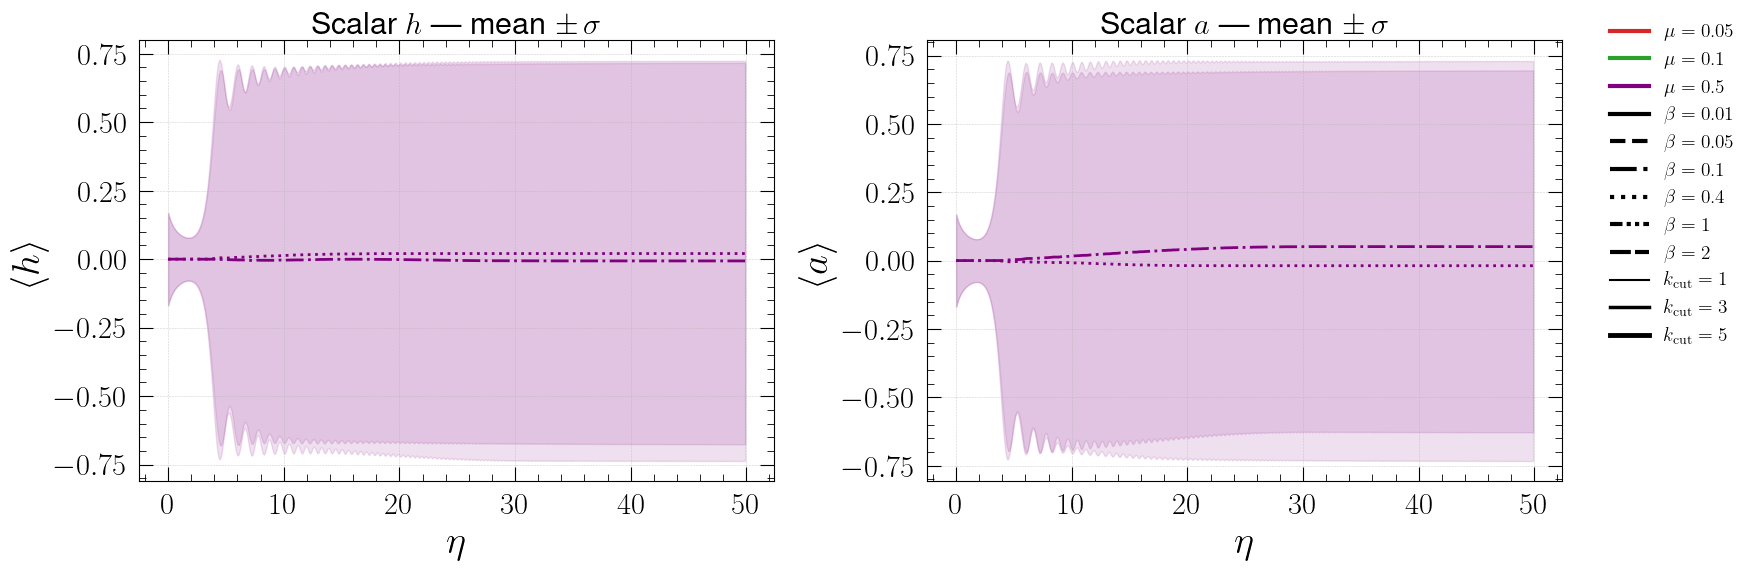

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

sub = [d for d in ready if (d["mu"] in [0.5] and d['beta'] in [0.1,0.4] and d['kcutoff'] in [3])]
for d in sub:
    for ax_idx, key in enumerate(["scalar_0", "scalar_1"]):
        sc = d[key]
        if sc is None:
            continue
        sigma = np.sqrt(np.maximum(sc["phi2"] - sc["phi"]**2, 0))
        axes[ax_idx].fill_between(sc["eta"],
                                  sc["phi"] - sigma, sc["phi"] + sigma,
                                  alpha=0.12, color=d["color"])
        axes[ax_idx].plot(sc["eta"], sc["phi"],
                          color=d["color"], linestyle=d["ls"], linewidth=2)

paper_ax(axes[0], ylabel=r"$\langle h \rangle$", title="Scalar $h$ — mean $\pm\,\sigma$")
paper_ax(axes[1], ylabel=r"$\langle a \rangle$", title="Scalar $a$ — mean $\pm\,\sigma$")
fig.legend(handles=make_legend_handles(), fontsize=14, frameon=False,
           loc='upper left', bbox_to_anchor=(1.01, 0.95), borderaxespad=0)
plt.tight_layout()
plt.show()

## Scale factor & Hubble rate

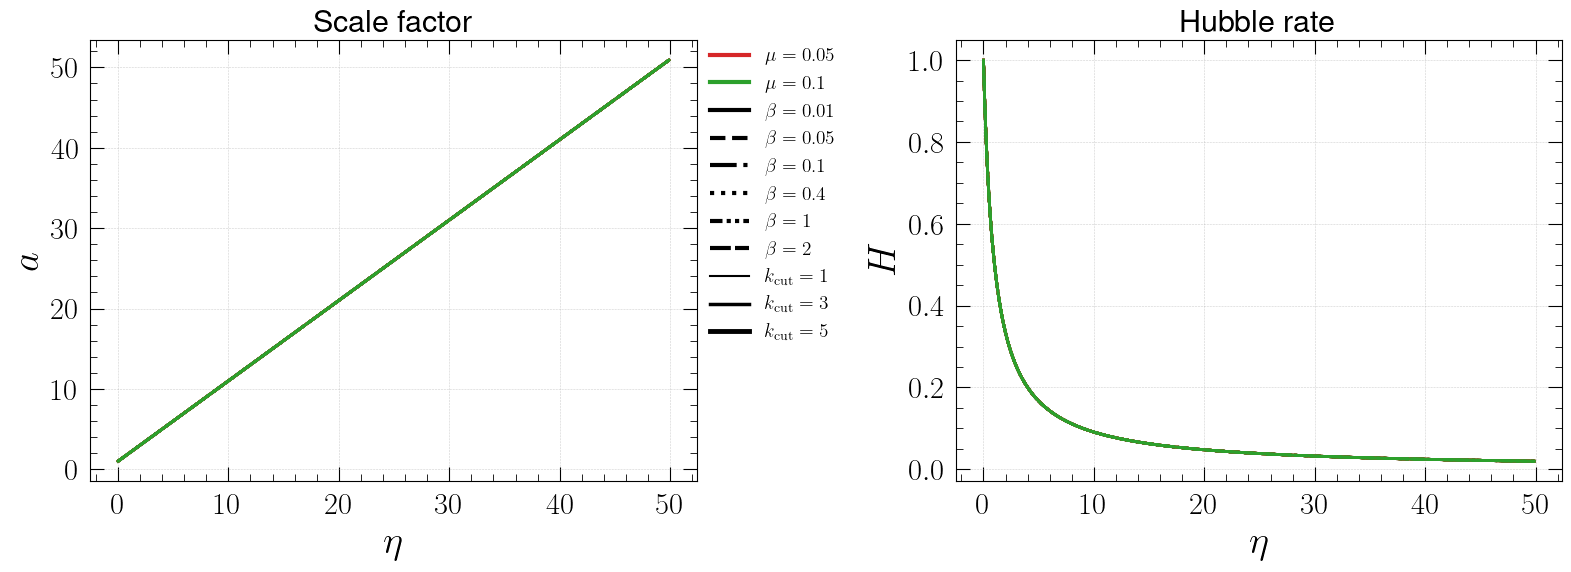

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for d in ready:
    sf = d["scale_factor"]
    axes[0].plot(sf["eta"], sf["a"],
                 color=d["color"], linestyle=d["ls"], linewidth=2, label=d["label"])
    axes[1].plot(sf["eta"], sf["H"],
                 color=d["color"], linestyle=d["ls"], linewidth=2)

paper_ax(axes[0], ylabel=r"$a$",  title="Scale factor")
paper_ax(axes[1], ylabel=r"$H$",  title="Hubble rate")
axes[0].legend(handles=make_legend_handles(), fontsize=14, frameon=False,
               loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

## Resolution validity check

Two checks per run:
1. **Type-1 wall resolved**: grid spacing `dx < δ̃₁ / a(η)` in comoving units  
2. **Type-2 wall resolved**: grid spacing `dx < δ̃₂ / a(η)` in comoving units  
   (Type-2 width is β-independent: δ̃₂ ≈ 0.71)

In [32]:
print(f"{'Label':42s}  {'δ̃₁':6s}  {'δ̃₂':6s}  "
      f"{'type-1 unresolved @η':>22s}  {'type-2 unresolved @η':>22s}")
print("-" * 110)

for d in ready:
    sf   = d["scale_factor"]
    mu   = d["mu"]
    beta = d["beta"]
    d1   = wall_width_type1(mu, beta)
    d2   = wall_width_type2()

    # comoving wall width shrinks as 1/a
    d1_com = d1 / sf["a"]
    d2_com = d2 / sf["a"]

    mask1 = DX > d1_com
    mask2 = DX > d2_com

    eta1 = sf["eta"][mask1][0] if mask1.any() else None
    eta2 = sf["eta"][mask2][0] if mask2.any() else None

    s1 = f"η = {eta1:.2f}" if eta1 is not None else "always resolved"
    s2 = f"η = {eta2:.2f}" if eta2 is not None else "always resolved"

    print(f"{d['label']:42s}  {d1:6.3f}  {d2:6.3f}  {s1:>22s}  {s2:>22s}")


Label                                       δ̃₁     δ̃₂       type-1 unresolved @η    type-2 unresolved @η
--------------------------------------------------------------------------------------------------------------
$\mu=0.05,\;\beta=0.01,\;k=1$                0.810   0.707                η = 3.20                η = 2.70
$\mu=0.05,\;\beta=0.05,\;k=1$                0.356   0.707                η = 0.90                η = 2.70
$\mu=0.05,\;\beta=0.1,\;k=1$                 0.246   0.707                η = 0.30                η = 2.70
$\mu=0.05,\;\beta=0.4,\;k=1$                 0.107   0.707                η = 0.00                η = 2.70
$\mu=0.05,\;\beta=1,\;k=1$                   0.053   0.707                η = 0.00                η = 2.70
$\mu=0.05,\;\beta=2,\;k=1$                   0.029   0.707                η = 0.00                η = 2.70
$\mu=0.1,\;\beta=0.01,\;k=1$                 1.146   0.707                η = 4.90                η = 2.70
$\mu=0.1,\;\beta=0.05,\;k=1$     

## kCutOff scan — IR sensitivity check

Fix `(mu, beta)` and overlay the three kCutOff values `[1, 3, 5]`.  
Each panel = one `(mu, beta)` pair; colour = kcutoff.  
If the curves agree the results are IR-insensitive; deviations flag sensitivity to initial-condition noise seeding.

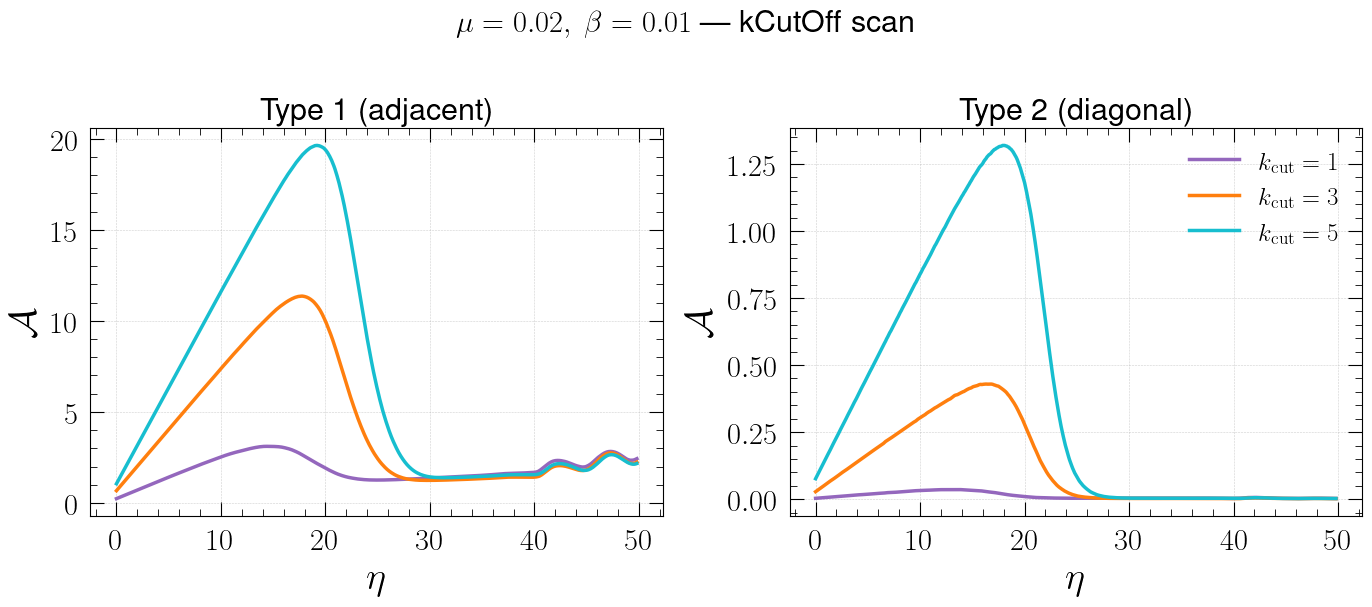

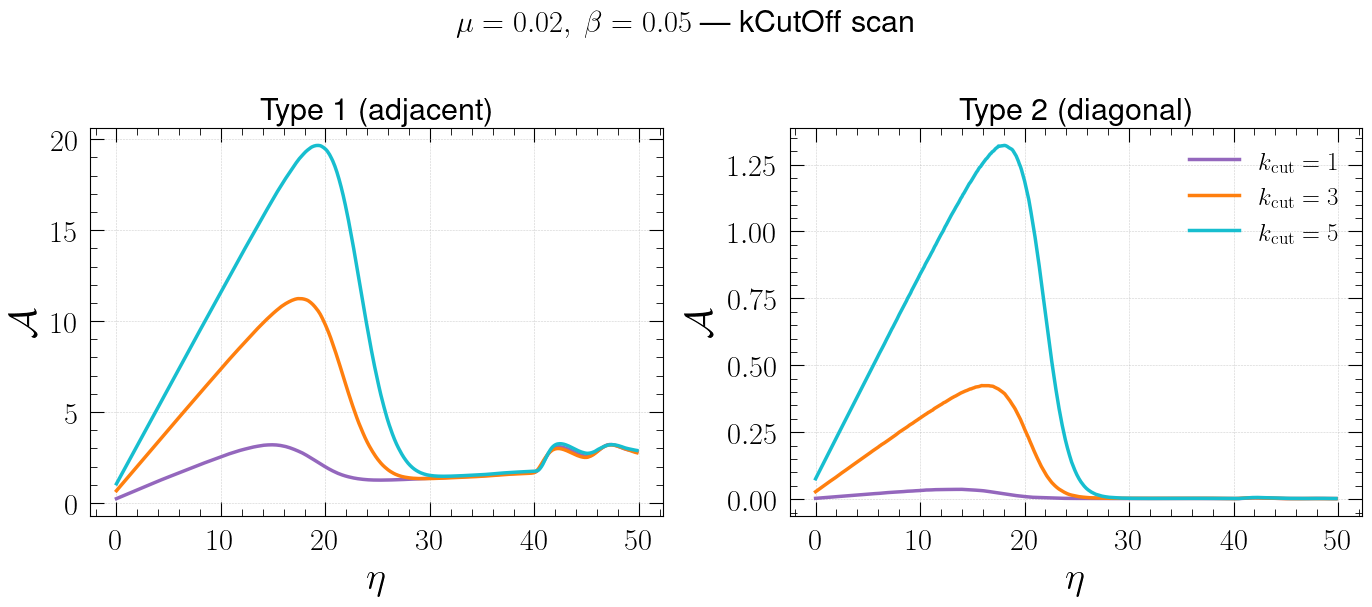

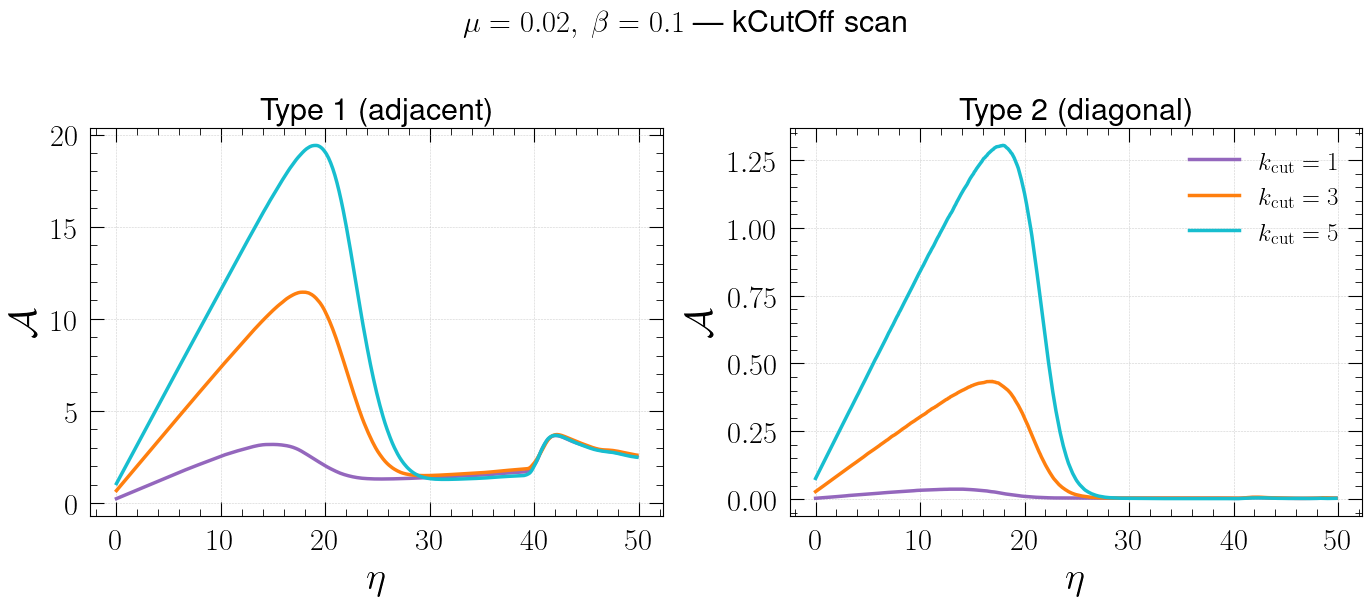

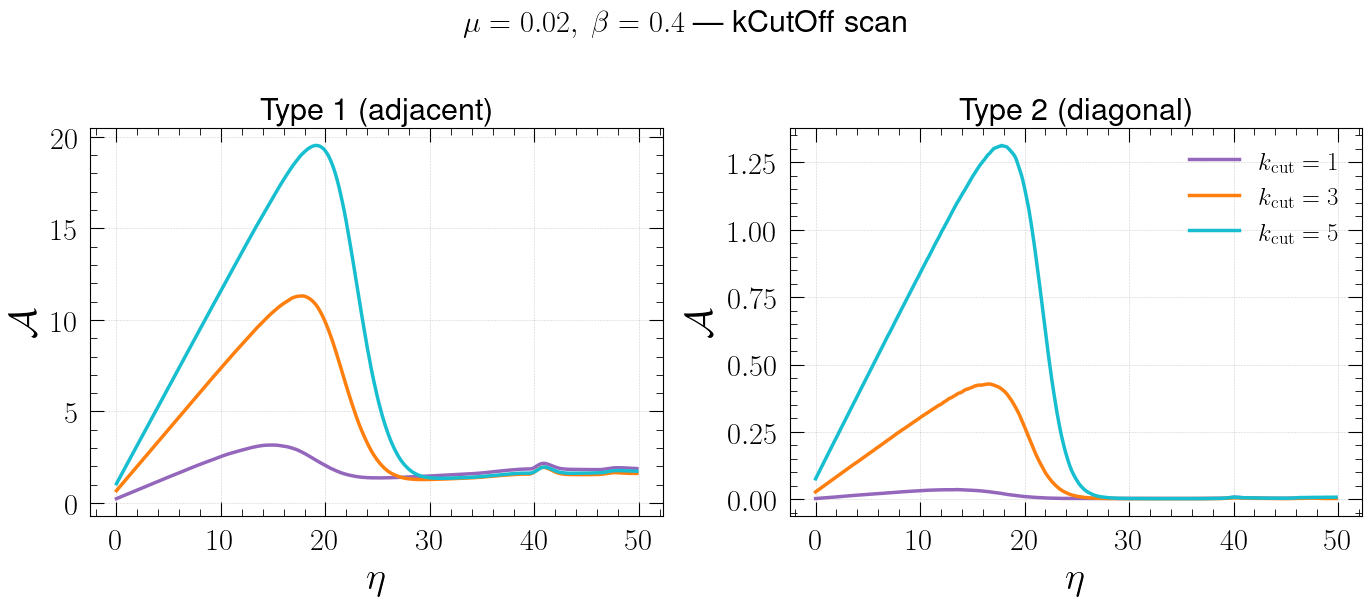

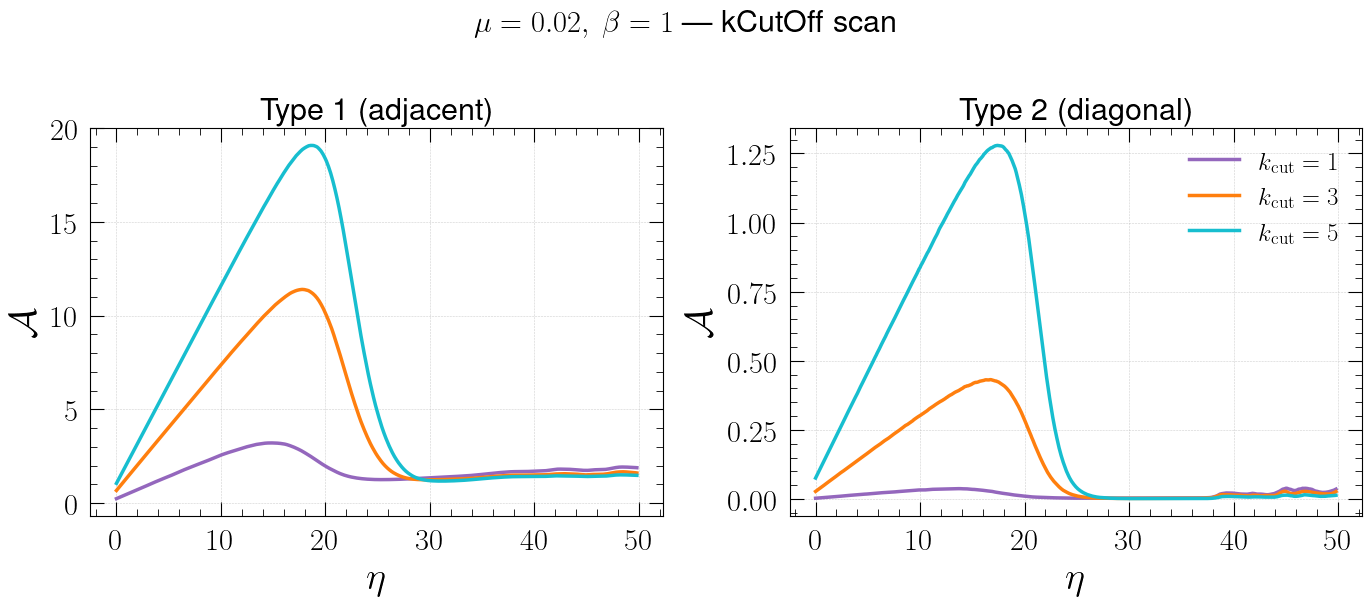

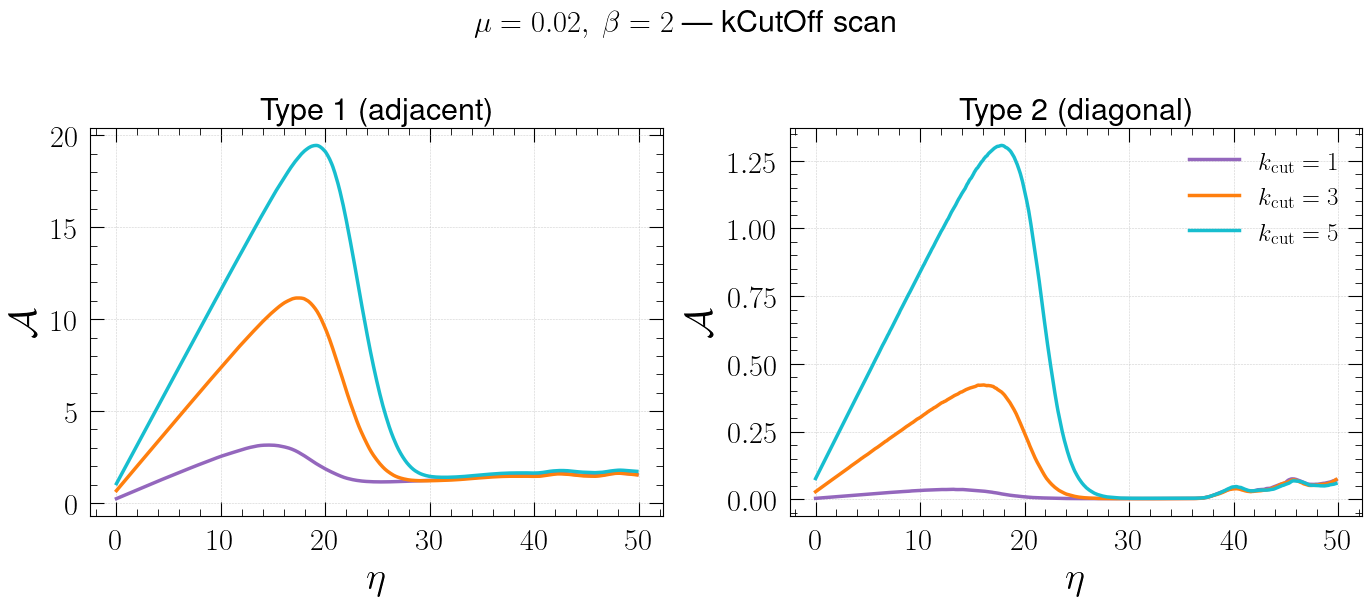

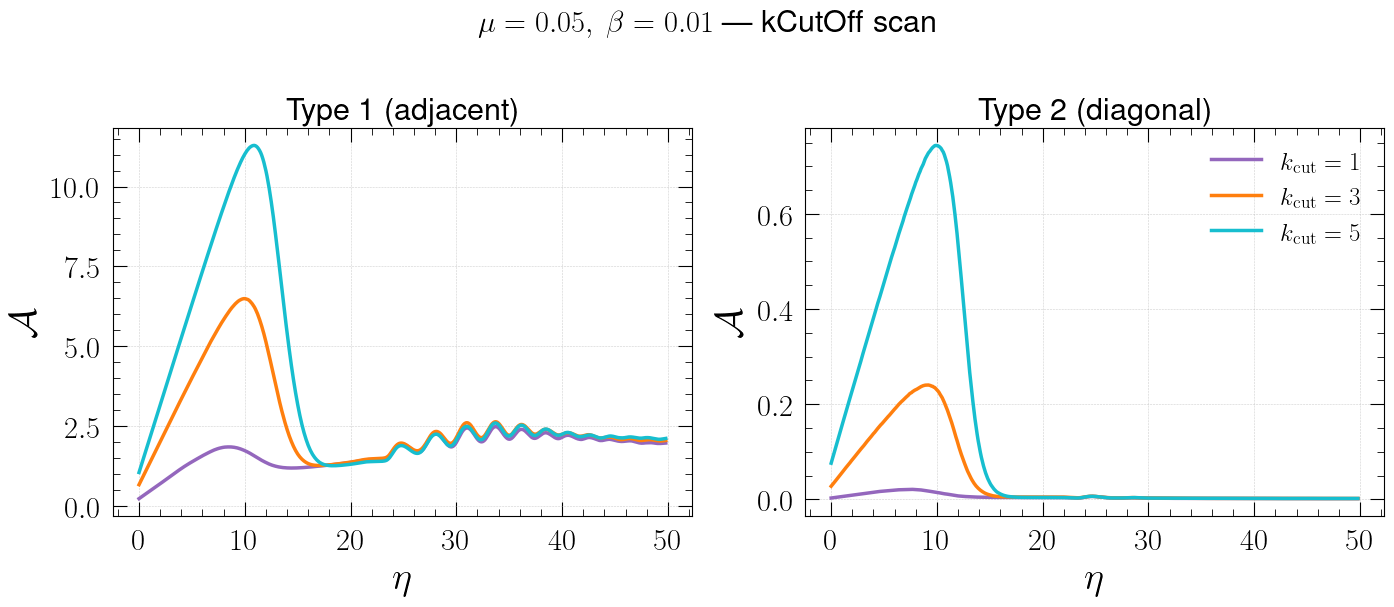

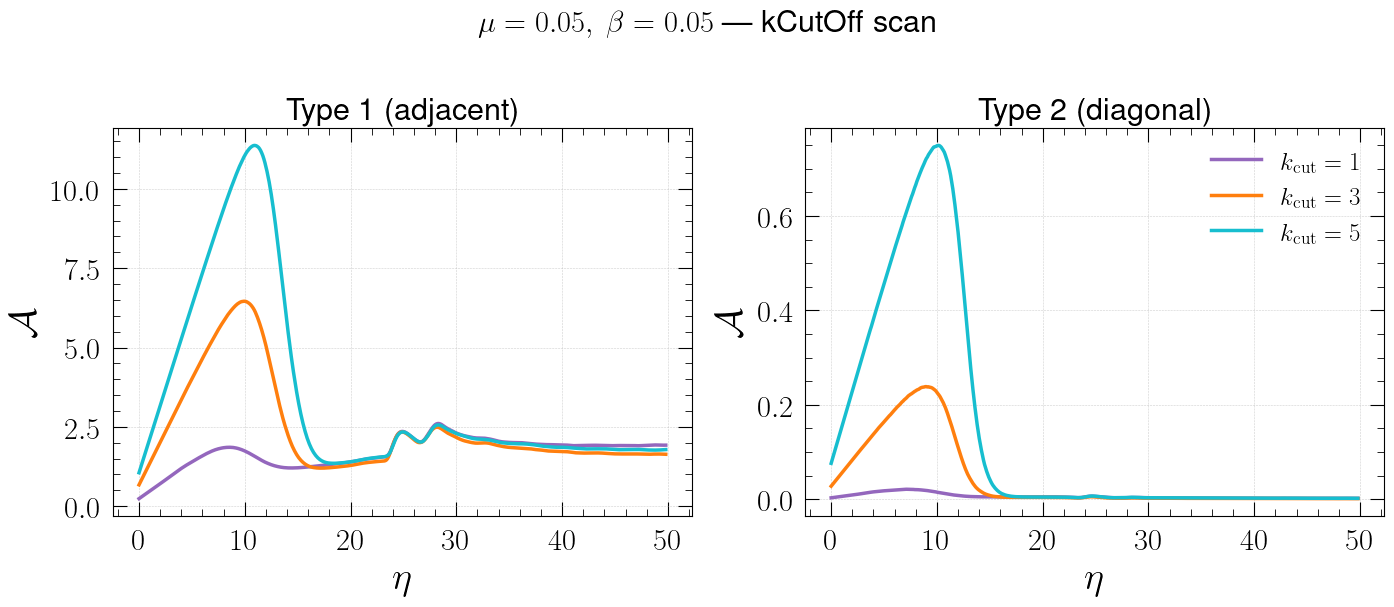

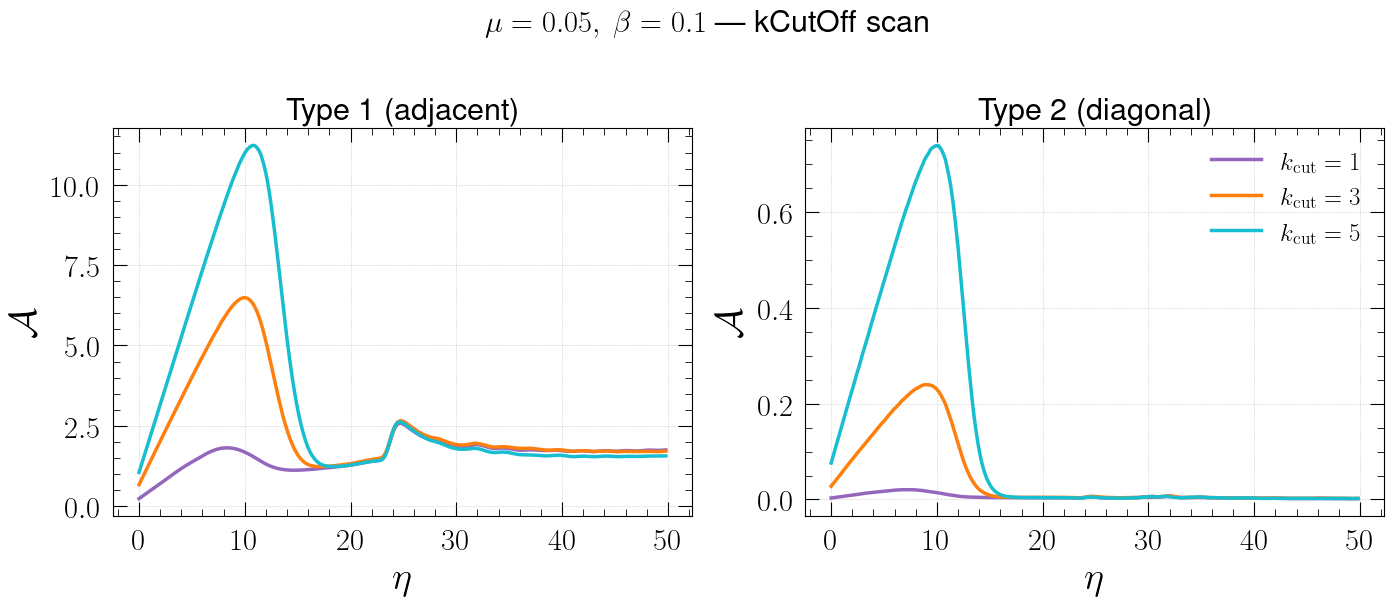

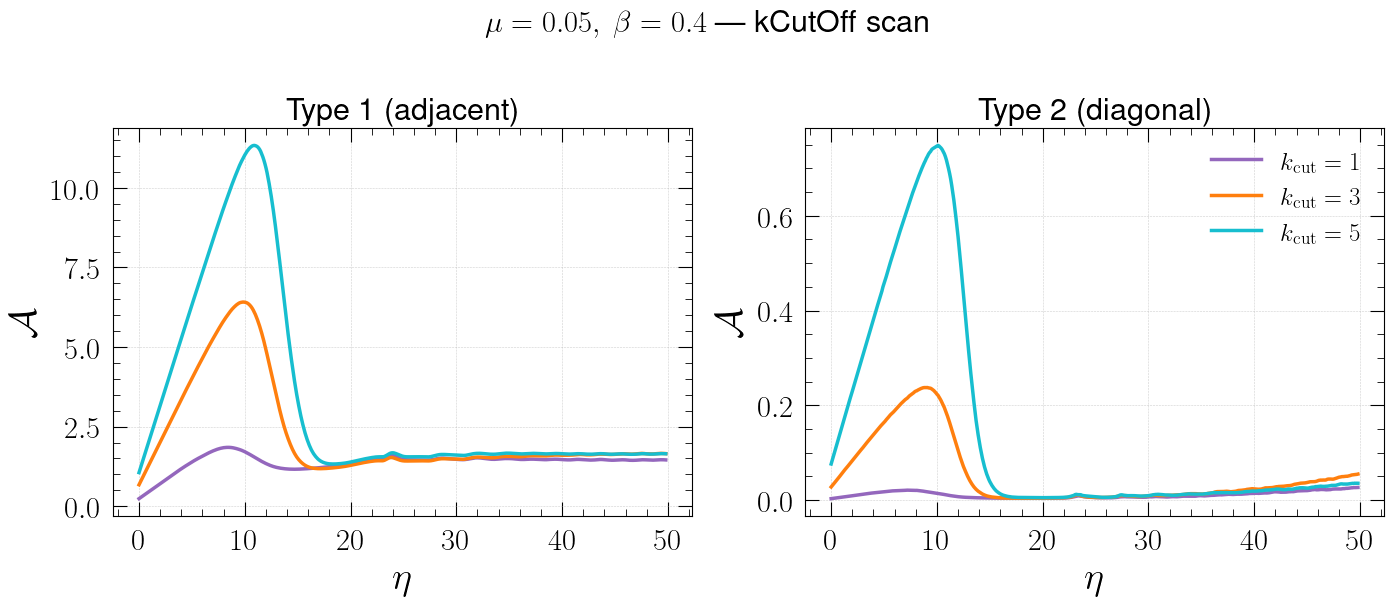

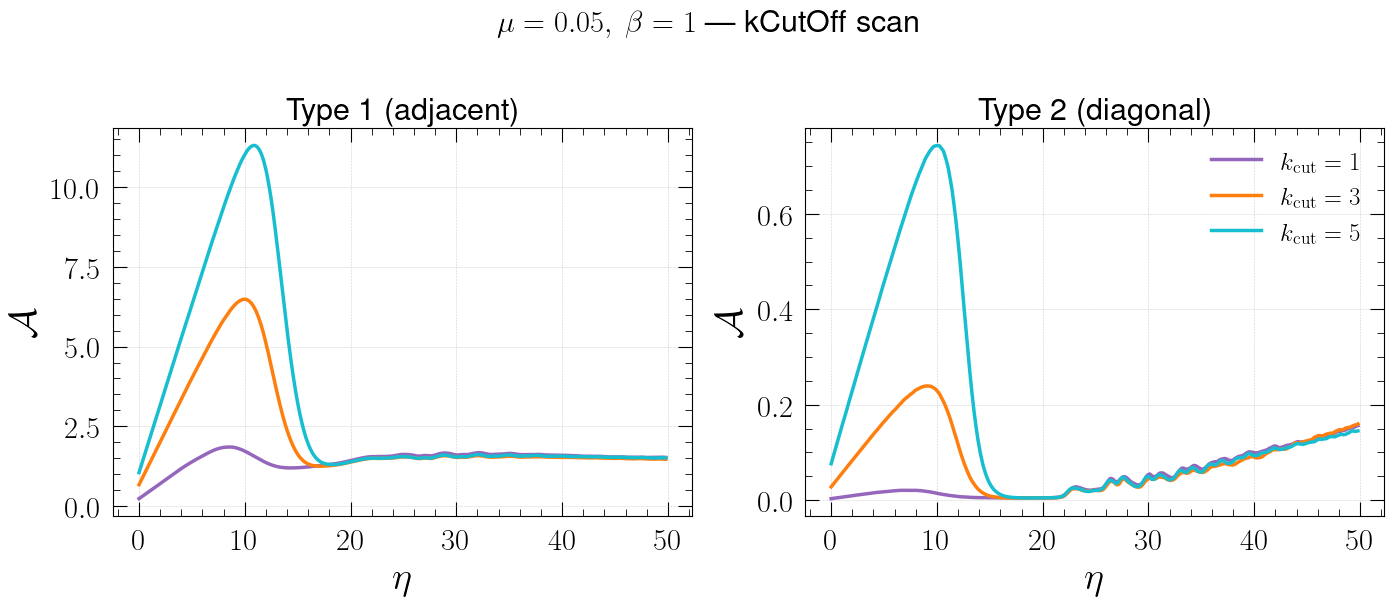

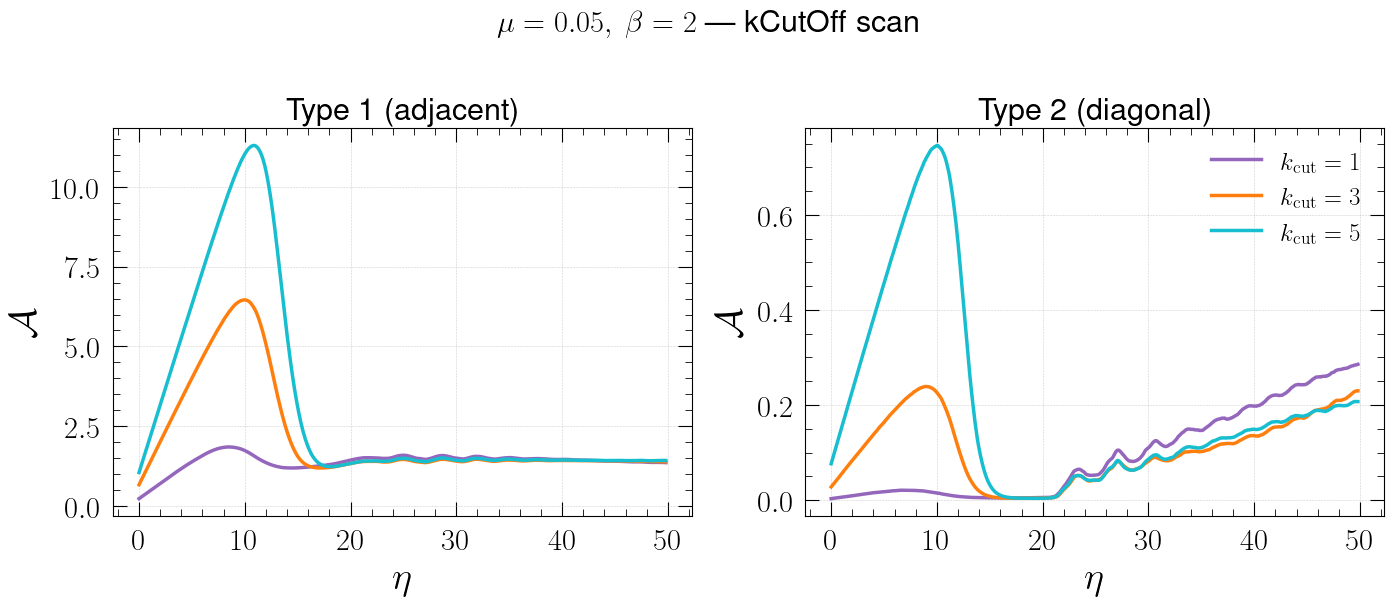

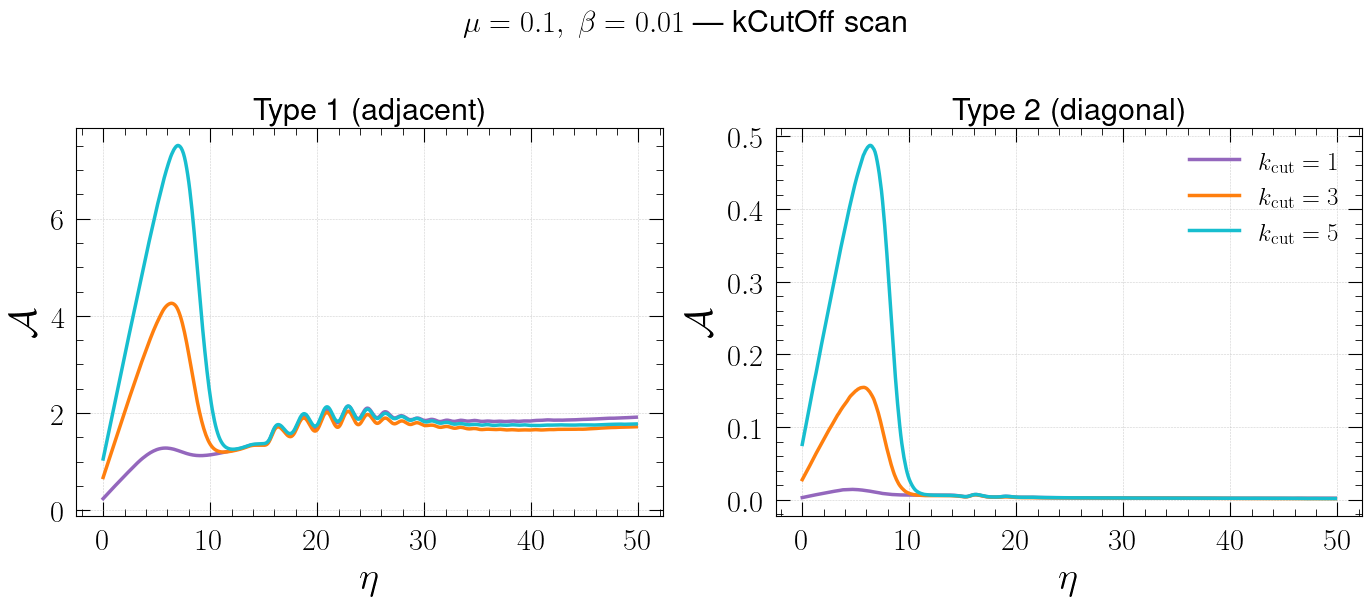

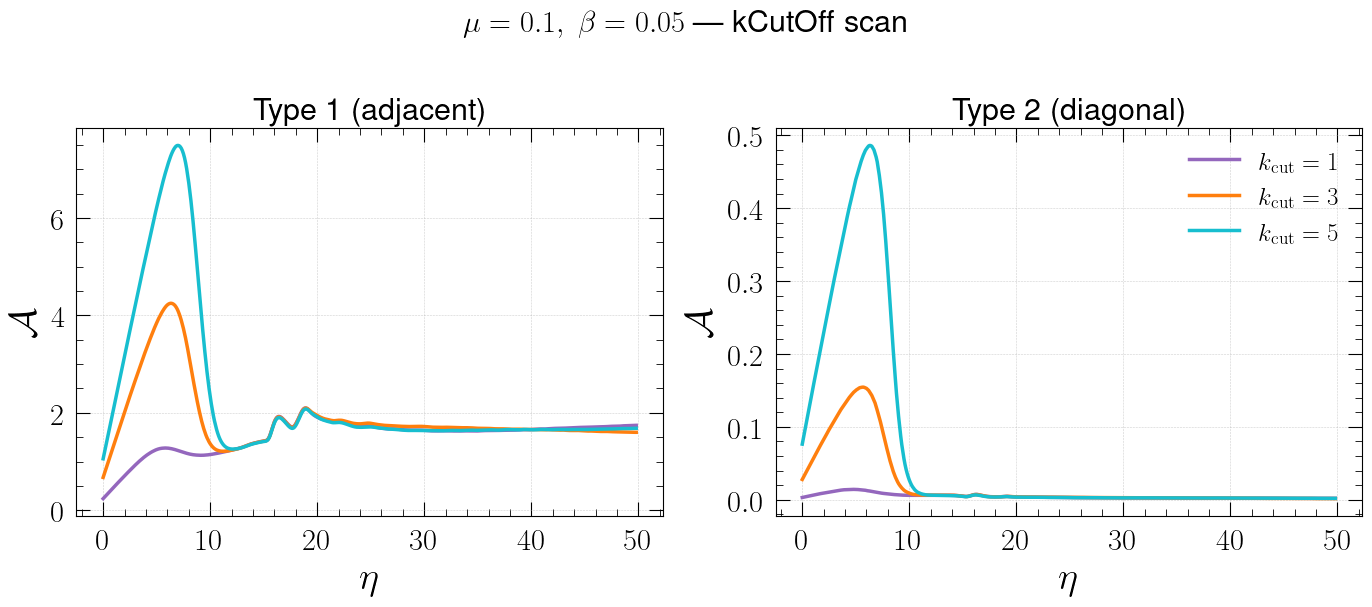

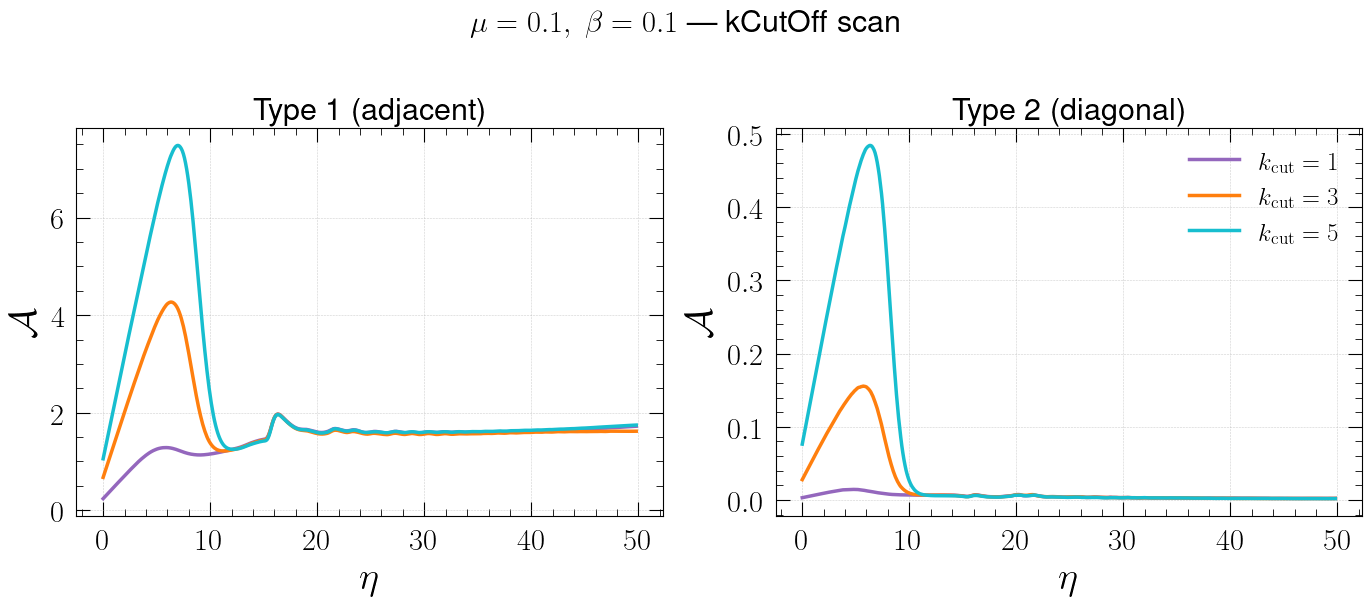

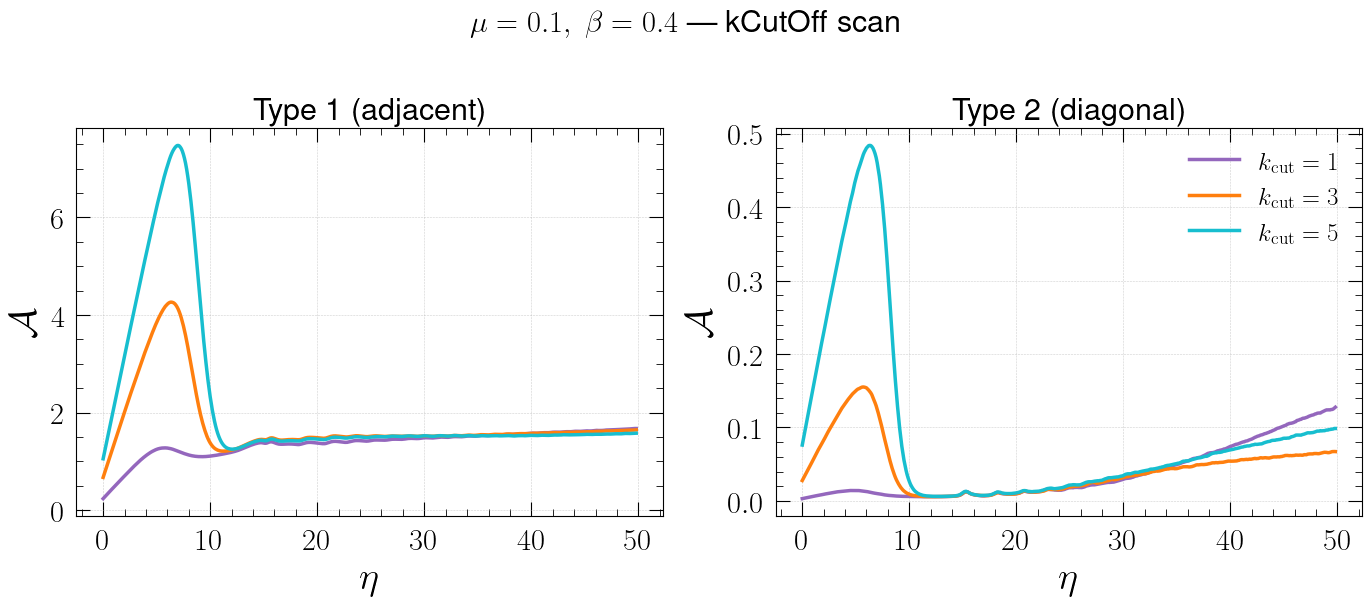

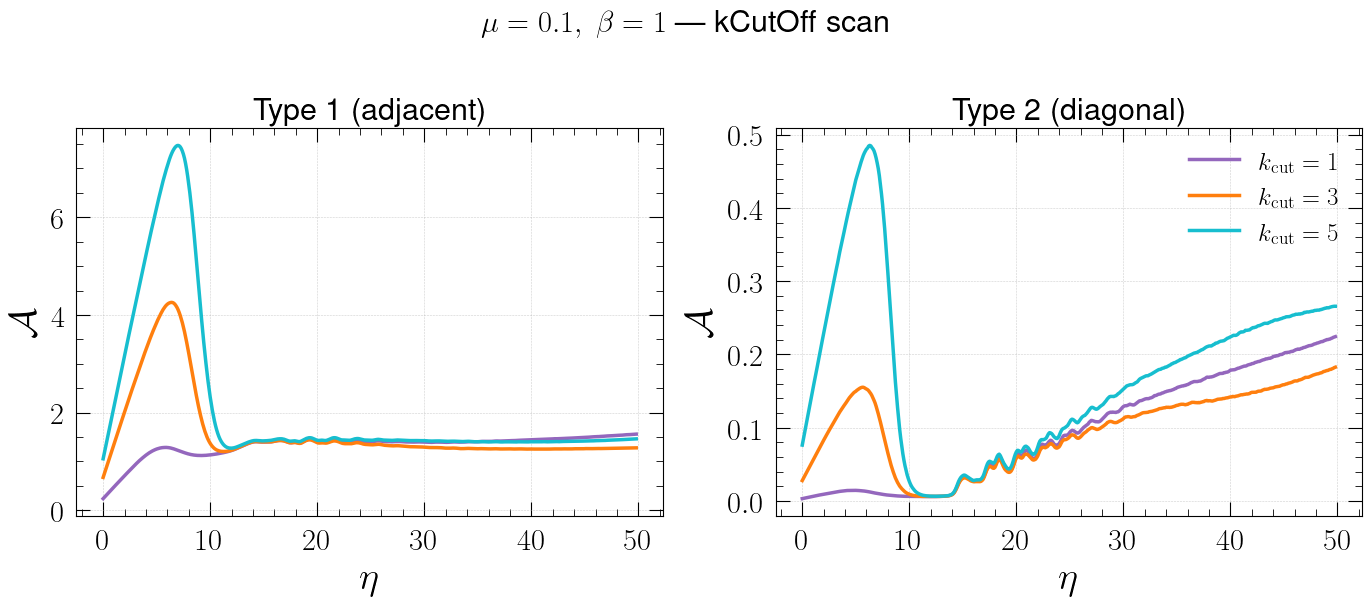

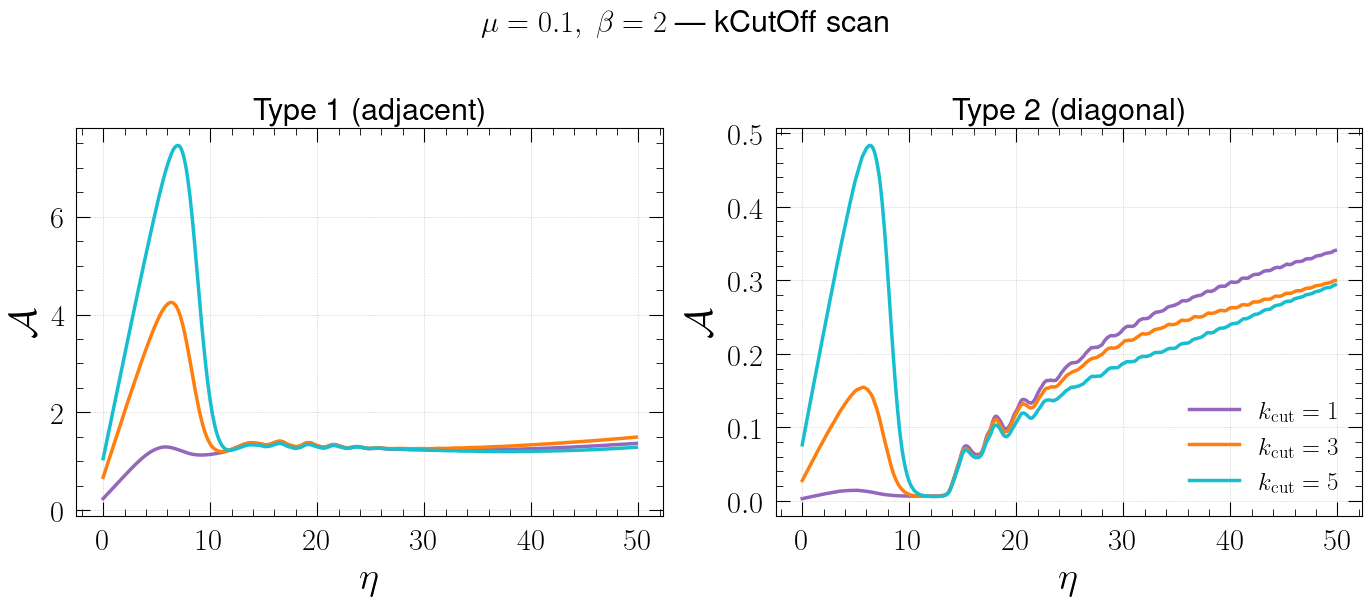

In [ ]:
kcutoff_colors = {1: '#9467bd', 3: '#ff7f0e', 5: '#17becf'}   # purple / orange / teal

# ── One figure per (mu, beta) pair; panels = wall type 1 & 2 ─────────────────
for mu_fix in MU_VALS:
    for beta_fix in BETA_VALS:
        sub = [d for d in ready if d["mu"] == mu_fix and d["beta"] == beta_fix]
        if not sub:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

        for d in sub:
            c = kcutoff_colors[d["kcutoff"]]
            for ax_idx, key in enumerate(["scal1", "scal2"]):
                eta, A = area_param(key, d)
                axes[ax_idx].plot(eta, A, color=c, linewidth=2.5,
                                  label=rf"$k_{{\rm cut}} = {d['kcutoff']}$")

        titles = ["Type 1 (adjacent)", "Type 2 (diagonal)"]
        for ax_idx in range(2):
            paper_ax(axes[ax_idx], ylabel=r"$\mathcal{A}$", title=titles[ax_idx])

        k_handles = [Line2D([0],[0], color=kcutoff_colors[k], lw=2.5,
                            label=rf"$k_{{\rm cut}} = {k}$") for k in KCUTOFF_VALS]
        axes[1].legend(handles=k_handles, fontsize=18, frameon=False)

        fig.suptitle(rf"$\mu = {mu_fix},\;\beta = {beta_fix}$  — kCutOff scan",
                     fontsize=22, y=1.02)
        plt.tight_layout()
        plt.savefig(f"Z4_kcutoff_scan_mu{float_str(mu_fix)}_beta{float_str(beta_fix)}.pdf",
                    bbox_inches="tight")
        plt.show()

In [ ]:
import h5py
f = h5py.File("/mt/user-batch/dpasari/results_z3_b0/gradient_energy_snapshot_scalar.h5", "r")

grp = f["E_S_G_0"]   # or E_S_K_1

times = sorted(grp.keys(), key=lambda s: float(s))
print(times)

arr = grp["2."][:]   # load into numpy array
print(arr.shape, arr.min(), arr.max())

Global fixed scale: 6.066641370325278e-08 0.0055479482446446704


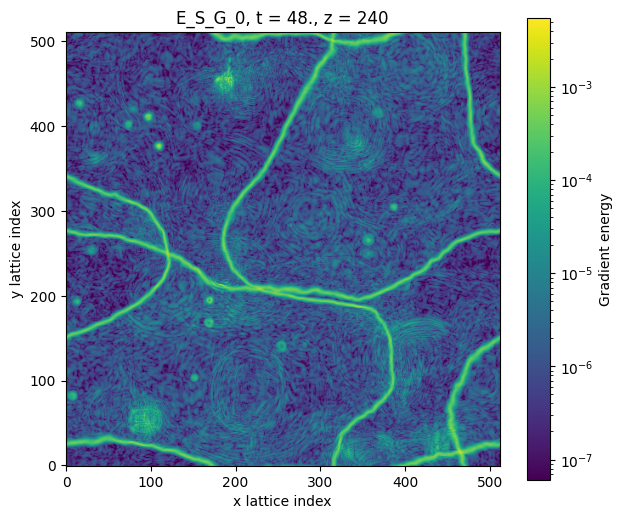

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm

f = h5py.File("/mt/user-batch/dpasari/scan_z4/results_z4_mu0p1_beta0p1_H1mu_k3/gradient_energy_snapshot_scalar.h5", "r")
grp = f["E_S_G_0"]
times = sorted(grp.keys(), key=lambda s: float(s))

z0 = 240

# -----------------------------------
# compute one global scale
# -----------------------------------
samples = []
for t in times:
    arr = grp[t][:, :, z0]
    positive = arr[arr > 0]
    if positive.size > 0:
        samples.append(positive.ravel())

all_vals = np.concatenate(samples)

vmin = np.percentile(all_vals, 1)
vmax = np.percentile(all_vals, 99.5)

print("Global fixed scale:", vmin, vmax)

# -----------------------------------
# animate
# -----------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

first = grp[times[-1]][:, :, z0]

im = ax.imshow(first.T,
               origin="lower",
               cmap="viridis",
               norm=LogNorm(vmin=vmin, vmax=vmax),
               animated=True)

plt.colorbar(im, ax=ax, label="Gradient energy")
title = ax.set_title(f"E_S_G_0, t = {times[-1]}, z = {z0}")
ax.set_xlabel("x lattice index")
ax.set_ylabel("y lattice index")
plt.show()

def update(i):
    t = times[i]
    data = grp[t][:, :, z0]
    im.set_array(data.T)
    title.set_text(f"E_S_G_0, t = {t}, z = {z0}")
    return im, title

ani = FuncAnimation(fig, update, frames=len(times), interval=400, blit=False)
ani.save("slice_z4_b_0p1_h_field.gif", writer="pillow", dpi=120,fps = 1)
plt.show()

In [ ]:
import numpy as np

def beta_paper(beta_code, mu=0.05):
    # code: beta_code = 3*lambda2/sqrt(8*lambda1), with v=1
    c = beta_code * np.sqrt(8.0) / 3.0
    x = mu * (c + np.sqrt(1.0 + c**2))   # sqrt(lambda1)
    lambda1 = x**2
    lambda2_code = c * x                  # code lambda2
    # paper: V has -lambda2_paper*(phi^4+phi*^4), code has -lambda2_code*mu*(...)
    # so lambda2_paper = mu * lambda2_code
    lambda2_paper = mu * lambda2_code
    beta_p = 2.0 * lambda2_paper / lambda1
    return beta_p

# Show mapping for test betas
betas_code = [0.01, 0.05, 0.1, 0.4, 1.0, 2.0]
print('beta_code -> beta_paper (mu independent of mapping formula)')
# Actually beta_paper depends on mu - let me check
for mu in [0.05, 0.1]:
    print(f'  mu={mu}:')
    for b in betas_code:
        print(f'    beta_code={b} -> beta_paper={beta_paper(b, mu):.4f}')

# Find beta_code corresponding to beta_paper = 1/3
# Analytically: beta_paper = 2*mu*beta_code*sqrt(8)/(3*sqrt(lambda1))
# sqrt(lambda1) = mu*(c+sqrt(1+c^2)) where c=beta_code*sqrt(8)/3
# so beta_paper = 2*beta_code*sqrt(8)/(3*(c+sqrt(1+c^2)))  -- mu cancels!
print()
print('Check: beta_paper is mu-independent?')
for b in betas_code:
    vals = [beta_paper(b, mu) for mu in [0.02,0.05,0.1,0.5]]
    print(f'  beta_code={b}: {vals}')

# Solve for beta_paper=1/3
from scipy.optimize import brentq
def eq(bc):
    return beta_paper(bc, mu=0.05) - 1/3
bc_star = brentq(eq, 0.1, 0.4)
print(f'\nbeta_code corresponding to beta_paper=1/3: {bc_star:.4f}')


beta_code -> beta_paper (mu independent of mapping formula)
  mu=0.05:
    beta_code=0.01 -> beta_paper=0.0187
    beta_code=0.05 -> beta_paper=0.0899
    beta_code=0.1 -> beta_paper=0.1716
    beta_code=0.4 -> beta_paper=0.5217
    beta_code=1.0 -> beta_paper=0.8138
    beta_code=2.0 -> beta_paper=0.9381
  mu=0.1:
    beta_code=0.01 -> beta_paper=0.0187
    beta_code=0.05 -> beta_paper=0.0899
    beta_code=0.1 -> beta_paper=0.1716
    beta_code=0.4 -> beta_paper=0.5217
    beta_code=1.0 -> beta_paper=0.8138
    beta_code=2.0 -> beta_paper=0.9381

Check: beta_paper is mu-independent?
  beta_code=0.01: [np.float64(0.018679241087722336), np.float64(0.01867924108772234), np.float64(0.01867924108772234), np.float64(0.018679241087722336)]
  beta_code=0.05: [np.float64(0.08994115814042357), np.float64(0.08994115814042357), np.float64(0.08994115814042357), np.float64(0.08994115814042357)]
  beta_code=0.1: [np.float64(0.1716202289125557), np.float64(0.17162022891255566), np.float64(0.171620228

# Average energies & scalar field — clean diagnostic plots

Below we restrict to a single `kCutOff` (default `K_FIX = 3`) and look at
**how energies and scalar-field means evolve as a function of $\eta$**
for the full $(\mu, \beta)$ grid.

Layout: rows = $\mu$, curves coloured by $\beta$.


In [ ]:
K_FIX = 3   # which kCutOff value to display

beta_cmap   = plt.cm.plasma(np.linspace(0.1, 0.85, len(BETA_VALS)))
beta_cmap   = dict(zip(BETA_VALS, beta_cmap))

def z4_style(d):
    return dict(color=beta_cmap[d['beta']], linewidth=2.2)

energy_keys = [
    ('E_tot', r'$E_{\rm tot}$'),
    ('Ek_1',  r'$E_{k,1}$ (h)'),
    ('Ek_2',  r'$E_{k,2}$ (a)'),
    ('Eg_1',  r'$E_{g,1}$ (h)'),
    ('Eg_2',  r'$E_{g,2}$ (a)'),
    ('Ev_1',  r'$E_{v,1}$  (mass)'),
    ('Ev_2',  r'$E_{v,2}$  ($\lambda_1$)'),
    ('Ev_3',  r'$E_{v,3}$  ($\lambda_2\mu$, Z4)'),
]

beta_handles_z4 = [Line2D([0],[0], color=beta_cmap[b], lw=3,
                          label=rf'$\beta = {b}$') for b in BETA_VALS]
print(f'Showing kCutOff = {K_FIX}')


## Energy components — 2×4 grid per $\mu$


In [ ]:
for mu_fix in MU_VALS:
    sub = [d for d in ready if d['mu'] == mu_fix and d['kcutoff'] == K_FIX]
    if not sub:
        print(f'No runs for mu={mu_fix}, k={K_FIX}')
        continue

    fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True)
    for ax, (key, title) in zip(axes.flat, energy_keys):
        for d in sub:
            en = d['energies']
            ax.plot(en['eta'], en[key], **z4_style(d))
        ax.set_title(title, fontsize=18)
        ax.grid(True, ls='--', lw=0.4, alpha=0.6)
        ax.tick_params(direction='in', top=True, right=True, labelsize=12)
        ax.minorticks_on()
    for ax in axes[-1]:
        ax.set_xlabel(r'$\eta$', fontsize=16)

    fig.suptitle(rf'$\mu = {mu_fix},\;k_{{\rm cut}} = {K_FIX}$', fontsize=22, y=1.02)
    fig.legend(handles=beta_handles_z4, fontsize=14, frameon=False,
               loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=len(BETA_VALS))
    plt.tight_layout()
    plt.savefig(f'Z4_energy_breakdown_mu{float_str(mu_fix)}_k{K_FIX}.pdf',
                bbox_inches='tight')
    plt.show()


## Summed energies (kinetic, gradient, potential, total)

One figure, rows = $\mu$, columns = energy group.


In [ ]:
n_mu = len(MU_VALS)
fig, axes = plt.subplots(n_mu, 4, figsize=(22, 5.5*n_mu),
                          sharex=True, squeeze=False)
groups = [
    (lambda en: en['E_tot'],                            r'$E_{\rm tot}$'),
    (lambda en: en['Ek_1'] + en['Ek_2'],                 r'$E_{\rm kin}$'),
    (lambda en: en['Eg_1'] + en['Eg_2'],                 r'$E_{\rm grad}$'),
    (lambda en: en['Ev_1'] + en['Ev_2'] + en['Ev_3'],    r'$E_{\rm pot}$'),
]
for i, mu_fix in enumerate(MU_VALS):
    sub = [d for d in ready if d['mu'] == mu_fix and d['kcutoff'] == K_FIX]
    for j, (fn, ttl) in enumerate(groups):
        ax = axes[i, j]
        for d in sub:
            en = d['energies']
            ax.plot(en['eta'], fn(en), **z4_style(d))
        if i == 0:
            ax.set_title(ttl, fontsize=18)
        if j == 0:
            ax.set_ylabel(rf'$\mu = {mu_fix}$', fontsize=16)
        if i == n_mu - 1:
            ax.set_xlabel(r'$\eta$', fontsize=15)
        ax.grid(True, ls='--', lw=0.4, alpha=0.6)
        ax.tick_params(direction='in', top=True, right=True, labelsize=12)
        ax.minorticks_on()
fig.legend(handles=beta_handles_z4, fontsize=14, frameon=False,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=len(BETA_VALS))
plt.tight_layout()
plt.savefig(f'Z4_energy_summed_k{K_FIX}.pdf', bbox_inches='tight')
plt.show()


## Scalar fields — mean ± σ

Panels-by-parameter: rows = $\mu$, columns = field index (0 = $h$, 1 = $a$).
Curves coloured by $\beta$; the shaded band is one standard deviation.


In [ ]:
n_mu = len(MU_VALS)
fig, axes = plt.subplots(n_mu, 2, figsize=(13, 5*n_mu),
                          sharex=True, squeeze=False)
field_titles = [r'$\phi_0$ ($h$, Higgs-like)', r'$\phi_1$ ($a$, axion-like)']

for i, mu_fix in enumerate(MU_VALS):
    sub = [d for d in ready if d['mu'] == mu_fix and d['kcutoff'] == K_FIX]
    for j, fkey in enumerate(('scalar_0', 'scalar_1')):
        ax = axes[i, j]
        for d in sub:
            sc = d.get(fkey)
            if sc is None: continue
            sigma = np.sqrt(np.maximum(sc['phi2'] - sc['phi']**2, 0.0))
            c = beta_cmap[d['beta']]
            ax.fill_between(sc['eta'], sc['phi'] - sigma, sc['phi'] + sigma,
                            alpha=0.12, color=c)
            ax.plot(sc['eta'], sc['phi'], color=c, linewidth=2.2)
        if i == 0:
            ax.set_title(field_titles[j], fontsize=16)
        if j == 0:
            ax.set_ylabel(rf'$\mu = {mu_fix}$', fontsize=15)
        if i == n_mu - 1:
            ax.set_xlabel(r'$\eta$', fontsize=15)
        ax.axhline(0, color='k', lw=0.5, alpha=0.4)
        ax.grid(True, ls='--', lw=0.4, alpha=0.6)
        ax.tick_params(direction='in', top=True, right=True, labelsize=12)
        ax.minorticks_on()

fig.legend(handles=beta_handles_z4, fontsize=14, frameon=False,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=len(BETA_VALS))
plt.tight_layout()
plt.savefig(f'Z4_scalar_mean_sigma_k{K_FIX}.pdf', bbox_inches='tight')
plt.show()


### RMS of each field
$\sqrt{\langle\phi^2\rangle}$ — captures both mean and fluctuations in one number.


In [ ]:
n_mu = len(MU_VALS)
fig, axes = plt.subplots(n_mu, 2, figsize=(13, 4.8*n_mu),
                          sharex=True, squeeze=False)
for i, mu_fix in enumerate(MU_VALS):
    sub = [d for d in ready if d['mu'] == mu_fix and d['kcutoff'] == K_FIX]
    for j, fkey in enumerate(('scalar_0', 'scalar_1')):
        ax = axes[i, j]
        for d in sub:
            sc = d.get(fkey)
            if sc is None: continue
            ax.plot(sc['eta'], np.sqrt(np.maximum(sc['phi2'], 0.0)), **z4_style(d))
        if i == 0:
            ax.set_title([r'$\sqrt{\langle\phi_0^2\rangle}$',
                          r'$\sqrt{\langle\phi_1^2\rangle}$'][j], fontsize=16)
        if j == 0:
            ax.set_ylabel(rf'$\mu = {mu_fix}$', fontsize=15)
        if i == n_mu - 1:
            ax.set_xlabel(r'$\eta$', fontsize=15)
        ax.grid(True, ls='--', lw=0.4, alpha=0.6)
        ax.tick_params(direction='in', top=True, right=True, labelsize=12)
        ax.minorticks_on()
fig.legend(handles=beta_handles_z4, fontsize=14, frameon=False,
           loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=len(BETA_VALS))
plt.tight_layout()
plt.savefig(f'Z4_scalar_rms_k{K_FIX}.pdf', bbox_inches='tight')
plt.show()
